# NCAA March Madness 2026 - Kaggle Competition

**Pipeline**: Feature Engineering → Model Training → Ensemble → Calibration → Submission

**Metric**: Brier Score (MSE of predicted probabilities)

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import sys
from pathlib import Path

# ML
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Project paths
PROJECT_DIR = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
DATA_DIR = PROJECT_DIR / 'march-machine-learning-mania-2026'
sys.path.insert(0, str(PROJECT_DIR))

print(f'Project: {PROJECT_DIR}')
print(f'Data:    {DATA_DIR}')
print(f'Files:   {len(list(DATA_DIR.glob("*.csv")))} CSV files')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: /Users/felixhuang/Desktop/2026 MM
Data:    /Users/felixhuang/Desktop/2026 MM/march-machine-learning-mania-2026
Files:   35 CSV files


## 1. Feature Engineering Pipeline

Runs the complete feature pipeline:
1. Basic season stats (win rate, margins, momentum)
2. Advanced stats (Four Factors, efficiency, tempo)
3. Strength of Schedule
4. Elo ratings (3 variants)
5. Massey Ordinals rankings (men only)
6. Contextual (coach, conference, seed)

In [2]:
from src.pipeline import run_feature_pipeline

matchup_df, feature_cols, team_features = run_feature_pipeline(
    target='train', use_massey=True
)

print(f'\nMatchup shape: {matchup_df.shape}')
print(f'Feature cols:  {len(feature_cols)}')
print(f'Seasons:       {matchup_df.Season.min()}-{matchup_df.Season.max()}')
print(f'Label mean:    {matchup_df.Label.mean():.3f}')

LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanced basketball statistics...
  -> 63 features

[3/7] S

In [3]:
# Quick look at data
print('Missing values per feature (top 20):')
missing = matchup_df[feature_cols].isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(20))

print(f'\nGames per season:')
print(matchup_df.groupby('Season').size().to_string())

Missing values per feature (top 20):
diff_rank_BPI         2522
diff_rank_USA         2214
diff_rank_AP          2204
diff_rank_LOG         2115
diff_rank_SPR         2115
diff_rank_ARG         2057
diff_rank_KPK         1786
diff_rank_REW         1722
diff_rank_MAS         1658
diff_rank_RPI         1602
diff_rank_DOK         1594
diff_rank_SAG         1536
diff_rank_SEL         1533
diff_rank_RTH         1468
diff_rank_WOL         1468
diff_rank_std_top     1402
diff_rank_std_all     1402
diff_rank_max_all     1402
diff_num_systems      1402
diff_rank_mean_top    1402
dtype: int64

Games per season:
Season
2003    127
2004    127
2005    127
2006    127
2007    127
2008    127
2009    127
2010    127
2011    130
2012    130
2013    130
2014    130
2015    130
2016    130
2017    130
2018    130
2019    130
2021    129
2022    134
2023    134
2024    134
2025    134


In [4]:
# === 1.5 Regular Season Auxiliary Training Data ===
from src.pipeline import build_matchup_features_vectorized
from src.data_loader import load_all_data, load_regular_season_compact

TOURNEY_WEIGHT = 5.0

_data_aug = load_all_data()
_compact  = load_regular_season_compact(_data_aug)
_compact  = _compact[
    (_compact['Season'] >= 2003) & (_compact['Season'] != 2020)
].copy()

_compact['TeamA'] = _compact[['WTeamID', 'LTeamID']].min(axis=1)
_compact['TeamB'] = _compact[['WTeamID', 'LTeamID']].max(axis=1)
_compact['Label'] = (_compact['WTeamID'] == _compact['TeamA']).astype(int)
rs_raw = _compact[['Season', 'TeamA', 'TeamB', 'Label', 'Gender']].reset_index(drop=True)

# build_matchup_features_vectorized expects RAW team-level column names
# (it will create diff_XXX internally); NOT the matchup-level feature_cols
raw_team_cols = [c for c in team_features.columns if c not in ['Season', 'TeamID', 'Gender']]
rs_feats = build_matchup_features_vectorized(rs_raw, team_features, raw_team_cols)

# The result has diff_XXX columns; add Label/Gender, then align to matchup_df columns.
# H2H and seed features are tournament-only → fill as NaN (imputed at train time).
rs_feats['Label']         = rs_raw['Label'].values
rs_feats['Gender']        = rs_raw['Gender'].values
rs_feats['is_tourney']    = 0
rs_feats['sample_weight'] = 1.0

# Tag original tournament data
matchup_df['is_tourney']    = 1
matchup_df['sample_weight'] = TOURNEY_WEIGHT

# Combine — tournament rows stay first, regular season appended
matchup_df_aug = pd.concat(
    [matchup_df, rs_feats.reset_index(drop=True)], ignore_index=True
)

# Gender-split augmented subsets (training only; validation stays tournament-only)
matchup_m_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'M'].copy()
matchup_w_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'W'].copy()

n_tourney = int(matchup_df['is_tourney'].sum())
n_rs      = int((matchup_df_aug['is_tourney'] == 0).sum())
print(f'=== Auxiliary Training Data ===')
print(f'  Tournament  (weight={TOURNEY_WEIGHT:.0f}): {n_tourney:,}')
print(f'  Regular season (weight=1): {n_rs:,}  ({n_rs/n_tourney:.1f}x more samples)')
print(f'  Total augmented:           {len(matchup_df_aug):,}')
print(f'  Men: {len(matchup_m_aug):,}  |  Women: {len(matchup_w_aug):,}')

Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']
=== Auxiliary Training Data ===
  Tournament  (weight=5): 2,851
  Regular season (weight=1): 235,150  (82.5x more samples)
  Total augmented:           238,001
  Men: 120,650  | 

## 2. EDA: Feature Distributions & Importance

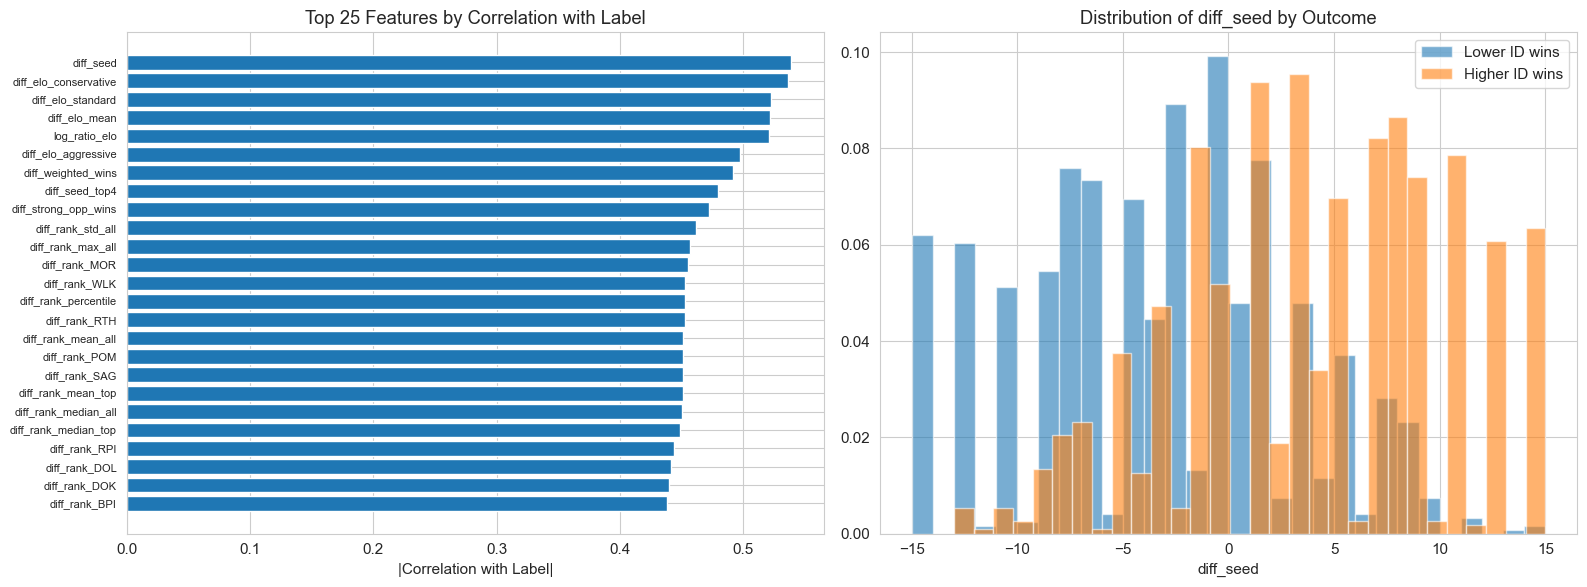

Top 15 correlated features:
diff_seed                0.538340
diff_elo_conservative    0.536350
diff_elo_standard        0.522587
diff_elo_mean            0.521830
log_ratio_elo            0.520619
diff_elo_aggressive      0.497013
diff_weighted_wins       0.491656
diff_seed_top4           0.479216
diff_strong_opp_wins     0.471767
diff_rank_std_all        0.461435
diff_rank_max_all        0.456883
diff_rank_MOR            0.455381
diff_rank_WLK            0.452618
diff_rank_percentile     0.452419
diff_rank_RTH            0.452298


In [5]:
# Top features correlation with Label
corr_with_label = matchup_df[feature_cols + ['Label']].corr()['Label'].drop('Label').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations
top_corr = corr_with_label.head(25)
axes[0].barh(range(len(top_corr)), top_corr.values)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index, fontsize=8)
axes[0].set_xlabel('|Correlation with Label|')
axes[0].set_title('Top 25 Features by Correlation with Label')
axes[0].invert_yaxis()

# Distribution of key features by win/loss
key_feat = 'diff_seed'
if key_feat in matchup_df.columns:
    data_plot = matchup_df.dropna(subset=[key_feat])
    axes[1].hist(data_plot[data_plot.Label == 1][key_feat], bins=30, alpha=0.6, label='Lower ID wins', density=True)
    axes[1].hist(data_plot[data_plot.Label == 0][key_feat], bins=30, alpha=0.6, label='Higher ID wins', density=True)
    axes[1].set_xlabel(key_feat)
    axes[1].set_title(f'Distribution of {key_feat} by Outcome')
    axes[1].legend()

plt.tight_layout()
plt.show()

print('Top 15 correlated features:')
print(corr_with_label.head(15).to_string())

## 3. Cross-Validation Setup

**Time-Series CV**: Train on seasons < N, validate on season N's tournament.

In [6]:
VAL_SEASONS = [2019, 2021, 2022, 2023, 2024, 2025]  # skip 2020 (COVID)

def get_cv_folds(df, val_seasons=VAL_SEASONS):
    """Generate time-series CV folds."""
    folds = []
    for vs in val_seasons:
        train_idx = df[df['Season'] < vs].index.tolist()
        val_idx = df[df['Season'] == vs].index.tolist()
        if len(val_idx) > 0:
            folds.append((train_idx, val_idx))
    return folds

cv_folds = get_cv_folds(matchup_df)
print(f'{len(cv_folds)} CV folds:')
for i, (tr, va) in enumerate(cv_folds):
    vs = matchup_df.loc[va[0], 'Season']
    print(f'  Fold {i}: Train {len(tr)} games (up to {vs-1}), Val {len(va)} games (season {vs})')

6 CV folds:
  Fold 0: Train 2056 games (up to 2018), Val 130 games (season 2019)
  Fold 1: Train 2186 games (up to 2020), Val 129 games (season 2021)
  Fold 2: Train 2315 games (up to 2021), Val 134 games (season 2022)
  Fold 3: Train 2449 games (up to 2022), Val 134 games (season 2023)
  Fold 4: Train 2583 games (up to 2023), Val 134 games (season 2024)
  Fold 5: Train 2717 games (up to 2024), Val 134 games (season 2025)


In [7]:
def evaluate_cv(matchup_df, feature_cols, model_fn, clip=(0.02, 0.98), verbose=True):
    """
    Run time-series CV with any model function.
    model_fn(X_train, y_train, X_val, y_val) -> predictions on X_val
    Returns per-fold and overall Brier Score.
    """
    folds = get_cv_folds(matchup_df)
    results = []
    all_preds, all_labels, all_seasons = [], [], []
    oof_preds = np.full(len(matchup_df), np.nan)
    models = []

    for i, (train_idx, val_idx) in enumerate(folds):
        X_tr = matchup_df.loc[train_idx, feature_cols]
        y_tr = matchup_df.loc[train_idx, 'Label']
        X_va = matchup_df.loc[val_idx, feature_cols]
        y_va = matchup_df.loc[val_idx, 'Label']
        season = matchup_df.loc[val_idx[0], 'Season']

        pred, model = model_fn(X_tr, y_tr, X_va, y_va)
        pred = np.clip(pred, clip[0], clip[1])

        oof_preds[val_idx] = pred
        brier = brier_score_loss(y_va, pred)
        ll = log_loss(y_va, pred)
        results.append({'season': season, 'n': len(y_va), 'brier': brier, 'logloss': ll})
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        all_seasons.extend([season] * len(y_va))
        models.append(model)

        if verbose:
            print(f'  Fold {i} (Season {season}): Brier={brier:.4f}  LogLoss={ll:.4f}  n={len(y_va)}')

    overall_brier = brier_score_loss(all_labels, all_preds)
    overall_ll = log_loss(all_labels, all_preds)
    if verbose:
        print(f'  OVERALL: Brier={overall_brier:.4f}  LogLoss={overall_ll:.4f}  n={len(all_labels)}')

    return {
        'overall_brier': overall_brier,
        'overall_logloss': overall_ll,
        'per_fold': pd.DataFrame(results),
        'oof_preds': oof_preds,
        'models': models,
    }

## 4. Baselines

In [8]:
# Baseline 1: Seed-only historical lookup
print('=== Seed-Only Baseline ===')
folds = get_cv_folds(matchup_df)
seed_preds_all, seed_labels_all = [], []

for train_idx, val_idx in folds:
    train = matchup_df.loc[train_idx].dropna(subset=['diff_seed'])
    val = matchup_df.loc[val_idx].dropna(subset=['diff_seed'])
    seed_wr = train.groupby('diff_seed')['Label'].mean().to_dict()
    preds = val['diff_seed'].map(seed_wr).fillna(0.5).clip(0.02, 0.98)
    season = val.iloc[0]['Season']
    brier = brier_score_loss(val['Label'], preds)
    print(f'  Season {season}: Brier={brier:.4f}  n={len(val)}')
    seed_preds_all.extend(preds.tolist())
    seed_labels_all.extend(val['Label'].tolist())

seed_brier = brier_score_loss(seed_labels_all, seed_preds_all)
print(f'  OVERALL: Brier={seed_brier:.4f}')

=== Seed-Only Baseline ===
  Season 2019: Brier=0.1643  n=130
  Season 2021: Brier=0.1982  n=129
  Season 2022: Brier=0.1998  n=134
  Season 2023: Brier=0.1911  n=134
  Season 2024: Brier=0.1635  n=134
  Season 2025: Brier=0.1451  n=134
  OVERALL: Brier=0.1770


In [9]:
# Baseline 2: Logistic Regression with key features
print('=== Logistic Regression Baseline ===')

lr_key_feats = [c for c in feature_cols if any(
    k in c for k in ['diff_seed', 'diff_elo_standard', 'diff_win_rate',
                      'diff_net_efficiency_mean', 'diff_rank_mean_all']
)]
print(f'  Using {len(lr_key_feats)} features: {lr_key_feats}')

def lr_model(X_tr, y_tr, X_va, y_va):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.fillna(0))
    X_va_s = scaler.transform(X_va.fillna(0))
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(X_tr_s, y_tr)
    return lr.predict_proba(X_va_s)[:, 1], (lr, scaler)

lr_results = evaluate_cv(matchup_df, lr_key_feats, lr_model)

=== Logistic Regression Baseline ===
  Using 7 features: ['diff_win_rate', 'diff_net_efficiency_mean', 'diff_elo_standard', 'diff_rank_mean_all', 'diff_seed', 'diff_seed_top4', 'diff_seed_top8']
  Fold 0 (Season 2019): Brier=0.1371  LogLoss=0.4196  n=130
  Fold 1 (Season 2021): Brier=0.1924  LogLoss=0.5574  n=129
  Fold 2 (Season 2022): Brier=0.1886  LogLoss=0.5528  n=134
  Fold 3 (Season 2023): Brier=0.1877  LogLoss=0.5492  n=134
  Fold 4 (Season 2024): Brier=0.1675  LogLoss=0.4951  n=134
  Fold 5 (Season 2025): Brier=0.1232  LogLoss=0.3941  n=134
  OVERALL: Brier=0.1661  LogLoss=0.4947  n=795


## 5. LightGBM — Baseline → Tuned

### 5.1 LightGBM Baseline

In [10]:
print('=== LightGBM Baseline (all features) ===')

def lgb_baseline(X_tr, y_tr, X_va, y_va):
    params = {
        'objective': 'binary', 'metric': 'binary_logloss',
        'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 5,
        'min_child_samples': 30, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5,
        'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'verbose': -1, 'n_jobs': -1, 'seed': 42,
    }
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    model = lgb.train(params, dtrain, num_boost_round=1000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
    return model.predict(X_va), model

lgb_base_results = evaluate_cv(matchup_df, feature_cols, lgb_baseline)

=== LightGBM Baseline (all features) ===
  Fold 0 (Season 2019): Brier=0.1509  LogLoss=0.4466  n=130
  Fold 1 (Season 2021): Brier=0.1881  LogLoss=0.5522  n=129
  Fold 2 (Season 2022): Brier=0.1826  LogLoss=0.5345  n=134
  Fold 3 (Season 2023): Brier=0.1908  LogLoss=0.5615  n=134
  Fold 4 (Season 2024): Brier=0.1765  LogLoss=0.5151  n=134
  Fold 5 (Season 2025): Brier=0.1365  LogLoss=0.4196  n=134
  OVERALL: Brier=0.1709  LogLoss=0.5049  n=795


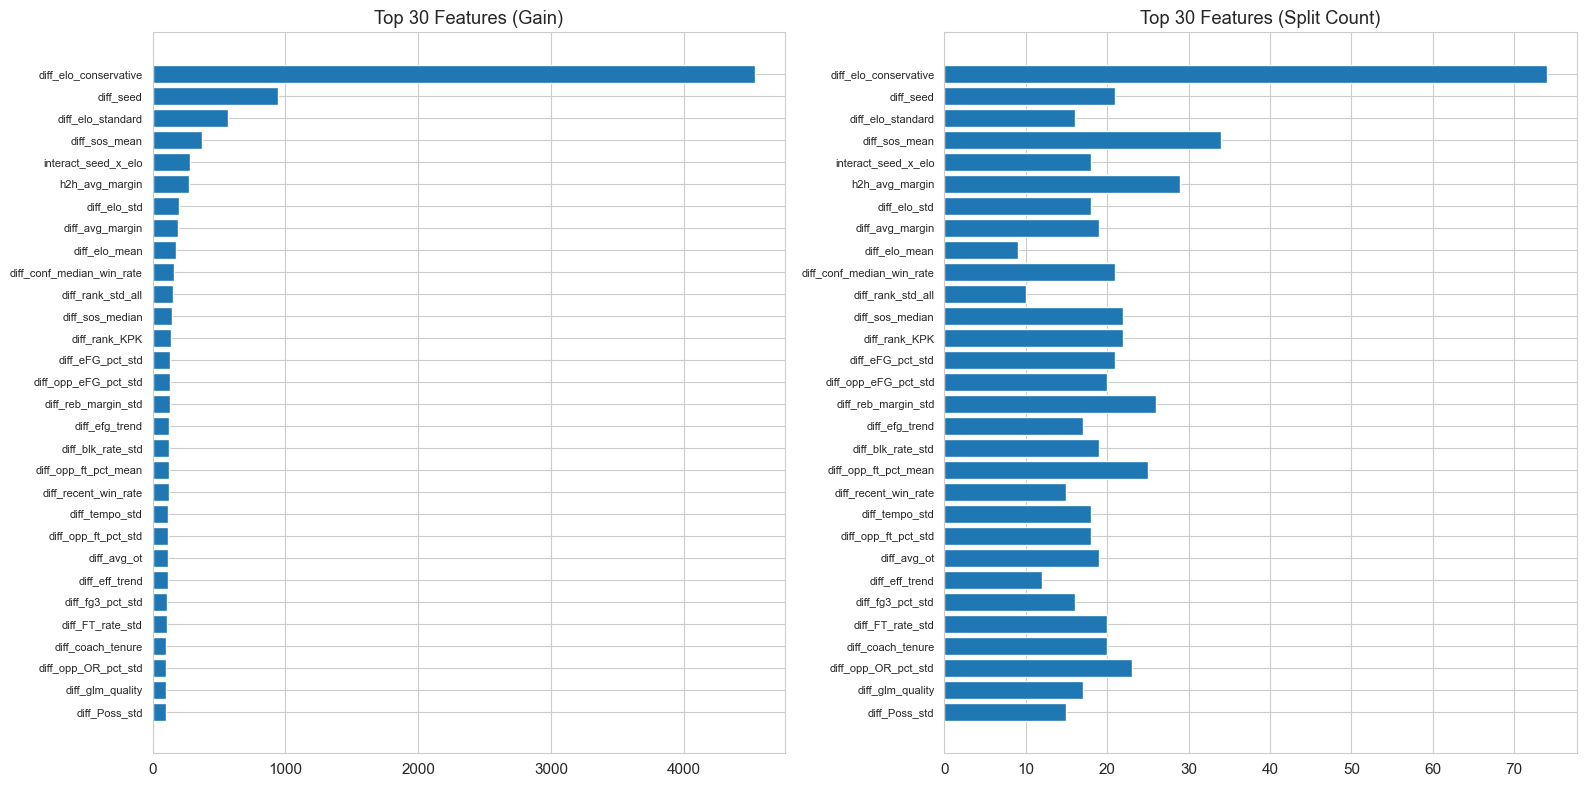

                  feature        gain  split
    diff_elo_conservative 4536.022254     74
                diff_seed  945.441695     21
        diff_elo_standard  569.469297     16
            diff_sos_mean  372.153827     34
      interact_seed_x_elo  278.781723     18
           h2h_avg_margin  274.007162     29
             diff_elo_std  199.886999     18
          diff_avg_margin  188.082969     19
            diff_elo_mean  179.355209      9
diff_conf_median_win_rate  157.563200     21
        diff_rank_std_all  154.642709     10
          diff_sos_median  145.321500     22
            diff_rank_KPK  135.847870     22
         diff_eFG_pct_std  130.873050     21
     diff_opp_eFG_pct_std  129.748579     20
      diff_reb_margin_std  128.983348     26
           diff_efg_trend  126.752860     17
        diff_blk_rate_std  124.941204     19
     diff_opp_ft_pct_mean  124.057188     25
     diff_recent_win_rate  121.926190     15
           diff_tempo_std  117.599519     18
      diff

In [11]:
# Feature importance from last fold
last_model = lgb_base_results['models'][-1]
fi = pd.DataFrame({
    'feature': feature_cols,
    'gain': last_model.feature_importance(importance_type='gain'),
    'split': last_model.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 30
fi_top = fi.head(top_n)

axes[0].barh(range(top_n), fi_top['gain'].values)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(fi_top['feature'].values, fontsize=8)
axes[0].set_title(f'Top {top_n} Features (Gain)')
axes[0].invert_yaxis()

axes[1].barh(range(top_n), fi_top['split'].values)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(fi_top['feature'].values, fontsize=8)
axes[1].set_title(f'Top {top_n} Features (Split Count)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(fi.head(30).to_string(index=False))

In [12]:
print(lgb_base_results['per_fold'].to_string(index=False))

 season   n    brier  logloss
   2019 130 0.150931 0.446601
   2021 129 0.188124 0.552224
   2022 134 0.182603 0.534484
   2023 134 0.190805 0.561507
   2024 134 0.176523 0.515110
   2025 134 0.136479 0.419630


### 5.2 Feature Selection — Keep Top-K by Importance

In [13]:
# Test different feature set sizes
print('=== Feature Selection Experiment ===')
fi_sorted = fi.sort_values('gain', ascending=False)
fi_sorted = fi_sorted[~fi_sorted['feature'].str.startswith('h2h_')]  # exclude h2h: unavailable in Stage2 -> train/inference distribution shift

results_by_k = {}
for k in [10, 20, 30, 50, 80, len(feature_cols)]:
    k = min(k, len(feature_cols))
    top_k_feats = fi_sorted['feature'].head(k).tolist()
    print(f'\n--- Top {k} features ---')
    res = evaluate_cv(matchup_df, top_k_feats, lgb_baseline, verbose=False)
    results_by_k[k] = res['overall_brier']
    print(f'  Brier = {res["overall_brier"]:.4f}')

print('\n=== Summary ===')
for k, brier in results_by_k.items():
    print(f'  Top-{k:3d} features: Brier = {brier:.4f}')

=== Feature Selection Experiment ===

--- Top 10 features ---
  Brier = 0.1662

--- Top 20 features ---
  Brier = 0.1639

--- Top 30 features ---
  Brier = 0.1663

--- Top 50 features ---
  Brier = 0.1673

--- Top 80 features ---
  Brier = 0.1673

--- Top 171 features ---
  Brier = 0.1717

=== Summary ===
  Top- 10 features: Brier = 0.1662
  Top- 20 features: Brier = 0.1639
  Top- 30 features: Brier = 0.1663
  Top- 50 features: Brier = 0.1673
  Top- 80 features: Brier = 0.1673
  Top-171 features: Brier = 0.1717


In [14]:
# Select best K
best_k = min(results_by_k, key=results_by_k.get)
selected_features = fi_sorted['feature'].head(best_k).tolist()
print(f'Best feature set: Top-{best_k} (Brier={results_by_k[best_k]:.4f})')
print(f'Selected features ({len(selected_features)}):')
for i, f in enumerate(selected_features):
    print(f'  {i+1:3d}. {f}')

Best feature set: Top-20 (Brier=0.1639)
Selected features (20):
    1. diff_elo_conservative
    2. diff_seed
    3. diff_elo_standard
    4. diff_sos_mean
    5. interact_seed_x_elo
    6. diff_elo_std
    7. diff_avg_margin
    8. diff_elo_mean
    9. diff_conf_median_win_rate
   10. diff_rank_std_all
   11. diff_sos_median
   12. diff_rank_KPK
   13. diff_eFG_pct_std
   14. diff_opp_eFG_pct_std
   15. diff_reb_margin_std
   16. diff_efg_trend
   17. diff_blk_rate_std
   18. diff_opp_ft_pct_mean
   19. diff_recent_win_rate
   20. diff_tempo_std


### 5.3 Hyperparameter Tuning (Optuna)

In [15]:
def optuna_lgb_objective(trial):
    """Optuna objective for LightGBM hyperparameter tuning."""
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    folds = get_cv_folds(matchup_df)
    all_preds, all_labels = [], []

    for train_idx, val_idx in folds:
        X_tr = matchup_df.loc[train_idx, selected_features]
        y_tr = matchup_df.loc[train_idx, 'Label']
        X_va = matchup_df.loc[val_idx, selected_features]
        y_va = matchup_df.loc[val_idx, 'Label']

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
        model = lgb.train(params, dtrain, num_boost_round=2000,
                          valid_sets=[dval],
                          callbacks=[lgb.early_stopping(50, verbose=False)])
        pred = np.clip(model.predict(X_va), 0.02, 0.98)
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())

    return brier_score_loss(all_labels, all_preds)

print('Running Optuna (100 trials)... this may take a few minutes.')
study = optuna.create_study(direction='minimize', study_name='lgb_tune')
study.optimize(optuna_lgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nBest trial: Brier = {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Running Optuna (100 trials)... this may take a few minutes.


Best trial: 64. Best value: 0.159539: 100%|██████████| 100/100 [02:34<00:00,  1.55s/it]


Best trial: Brier = 0.1595
Best params:
  learning_rate: 0.10221986077074957
  num_leaves: 20
  max_depth: 6
  min_child_samples: 72
  feature_fraction: 0.5004120150205564
  bagging_fraction: 0.7681892985334657
  bagging_freq: 2
  reg_alpha: 0.0268019203233604
  reg_lambda: 0.022981674850181717


In [16]:
# Evaluate tuned LightGBM
best_lgb_params = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbose': -1, 'n_jobs': -1, 'seed': 42,
    **study.best_params
}

def lgb_tuned(X_tr, y_tr, X_va, y_va):
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    model = lgb.train(best_lgb_params, dtrain, num_boost_round=2000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False)])
    return model.predict(X_va), model

print('=== Tuned LightGBM ===')
lgb_tuned_results = evaluate_cv(matchup_df, selected_features, lgb_tuned)

=== Tuned LightGBM ===
  Fold 0 (Season 2019): Brier=0.1268  LogLoss=0.3879  n=130
  Fold 1 (Season 2021): Brier=0.1785  LogLoss=0.5233  n=129
  Fold 2 (Season 2022): Brier=0.1731  LogLoss=0.5173  n=134
  Fold 3 (Season 2023): Brier=0.1897  LogLoss=0.5547  n=134
  Fold 4 (Season 2024): Brier=0.1663  LogLoss=0.4887  n=134
  Fold 5 (Season 2025): Brier=0.1226  LogLoss=0.3780  n=134
  OVERALL: Brier=0.1595  LogLoss=0.4751  n=795


## 6. XGBoost

In [17]:
print('=== XGBoost ===')

def xgb_model(X_tr, y_tr, X_va, y_va):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'learning_rate': 0.05, 'max_depth': 5,
        'min_child_weight': 30, 'subsample': 0.8,
        'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'seed': 42, 'verbosity': 0,
    }
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_va, label=y_va)
    model = xgb.train(params, dtrain, num_boost_round=1000,
                      evals=[(dval, 'val')],
                      early_stopping_rounds=50, verbose_eval=False)
    return model.predict(dval), model

xgb_results = evaluate_cv(matchup_df, selected_features, xgb_model)

=== XGBoost ===
  Fold 0 (Season 2019): Brier=0.1423  LogLoss=0.4276  n=130
  Fold 1 (Season 2021): Brier=0.1913  LogLoss=0.5582  n=129
  Fold 2 (Season 2022): Brier=0.1814  LogLoss=0.5393  n=134
  Fold 3 (Season 2023): Brier=0.2002  LogLoss=0.5806  n=134
  Fold 4 (Season 2024): Brier=0.1666  LogLoss=0.4908  n=134
  Fold 5 (Season 2025): Brier=0.1269  LogLoss=0.3953  n=134
  OVERALL: Brier=0.1681  LogLoss=0.4986  n=795


## 7. CatBoost

In [18]:
print('=== CatBoost ===')

def catboost_model(X_tr, y_tr, X_va, y_va):
    model = cb.CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=5,
        l2_leaf_reg=3.0, subsample=0.8,
        early_stopping_rounds=50, verbose=0, random_seed=42,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
    pred = model.predict_proba(X_va)[:, 1]
    return pred, model

cb_results = evaluate_cv(matchup_df, selected_features, catboost_model)

=== CatBoost ===
  Fold 0 (Season 2019): Brier=0.1410  LogLoss=0.4209  n=130
  Fold 1 (Season 2021): Brier=0.1921  LogLoss=0.5538  n=129
  Fold 2 (Season 2022): Brier=0.1758  LogLoss=0.5239  n=134
  Fold 3 (Season 2023): Brier=0.1901  LogLoss=0.5541  n=134
  Fold 4 (Season 2024): Brier=0.1591  LogLoss=0.4728  n=134
  Fold 5 (Season 2025): Brier=0.1306  LogLoss=0.4094  n=134
  OVERALL: Brier=0.1647  LogLoss=0.4891  n=795


## 8. Logistic Regression (full selected features)

In [19]:
print('=== Logistic Regression (selected features) ===')

def lr_full_model(X_tr, y_tr, X_va, y_va):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.fillna(0))
    X_va_s = scaler.transform(X_va.fillna(0))
    lr = LogisticRegression(C=0.5, max_iter=2000, solver='lbfgs')
    lr.fit(X_tr_s, y_tr)
    return lr.predict_proba(X_va_s)[:, 1], (lr, scaler)

lr_full_results = evaluate_cv(matchup_df, selected_features, lr_full_model)

=== Logistic Regression (selected features) ===
  Fold 0 (Season 2019): Brier=0.1548  LogLoss=0.4563  n=130
  Fold 1 (Season 2021): Brier=0.1909  LogLoss=0.5518  n=129
  Fold 2 (Season 2022): Brier=0.1770  LogLoss=0.5194  n=134
  Fold 3 (Season 2023): Brier=0.1917  LogLoss=0.5628  n=134
  Fold 4 (Season 2024): Brier=0.1585  LogLoss=0.4720  n=134
  Fold 5 (Season 2025): Brier=0.1275  LogLoss=0.3998  n=134
  OVERALL: Brier=0.1666  LogLoss=0.4935  n=795


## 9. Model Comparison

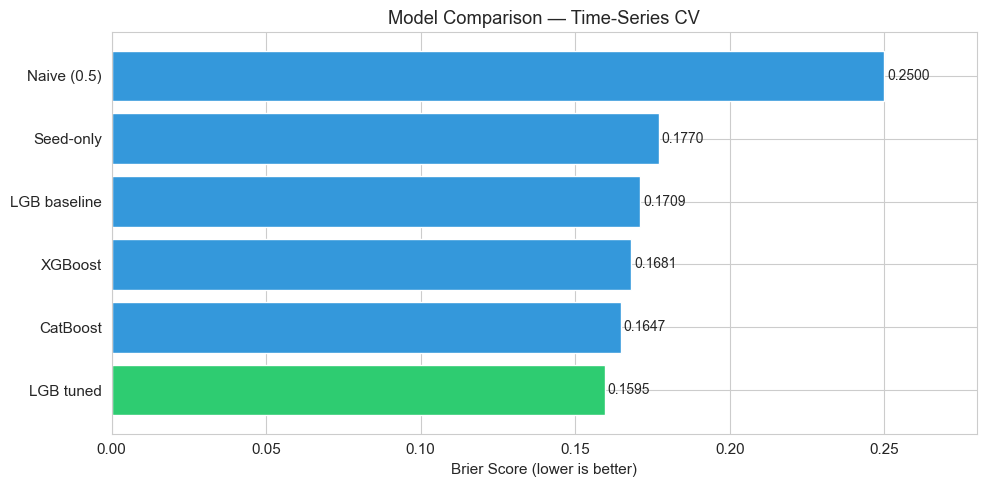

       Model  Brier Score
   LGB tuned     0.159539
    CatBoost     0.164734
     XGBoost     0.168102
LGB baseline     0.170903
   Seed-only     0.176950
 Naive (0.5)     0.250000


In [20]:
model_scores = {
    'Naive (0.5)': 0.25,
    'Seed-only': seed_brier,
    'LGB baseline': lgb_base_results['overall_brier'],
    'LGB tuned': lgb_tuned_results['overall_brier'],
    'XGBoost': xgb_results['overall_brier'],
    'CatBoost': cb_results['overall_brier'],
}

scores_df = pd.DataFrame([
    {'Model': k, 'Brier Score': v} for k, v in model_scores.items()
]).sort_values('Brier Score')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(scores_df))]
ax.barh(scores_df['Model'], scores_df['Brier Score'], color=colors)
ax.set_xlabel('Brier Score (lower is better)')
ax.set_title('Model Comparison — Time-Series CV')
for i, (_, row) in enumerate(scores_df.iterrows()):
    ax.text(row['Brier Score'] + 0.001, i, f"{row['Brier Score']:.4f}", va='center', fontsize=10)
ax.set_xlim(0, 0.28)
plt.tight_layout()
plt.show()

print(scores_df.to_string(index=False))

## 9.5 Gender-Specific Models (3.1)

Train **separate LGB / XGB / CatBoost / LR** models for men and women.

Key insight: Women lack Massey Ordinals data → a unified model forces ~50 % NaN imputation for women's Massey features, hurting women's predictions. Separating lets each gender use only features it actually has.

In [21]:
# === 9.5.1 Gender split + per-gender feature selection ===
matchup_m = matchup_df[matchup_df['Gender'] == 'M'].copy()
matchup_w = matchup_df[matchup_df['Gender'] == 'W'].copy()
print(f'Men: {len(matchup_m)} games | Women: {len(matchup_w)} games')

# Drop features that are >50% NaN within each gender's data
m_miss = matchup_m[selected_features].isnull().mean()
w_miss = matchup_w[selected_features].isnull().mean()
selected_features_m = [f for f in selected_features if m_miss[f] < 0.5]
selected_features_w = [f for f in selected_features if w_miss[f] < 0.5]
dropped_for_w = sorted(set(selected_features_m) - set(selected_features_w))
print(f'Men features:   {len(selected_features_m)}')
print(f'Women features: {len(selected_features_w)} ({len(dropped_for_w)} dropped, mostly Massey/men-only)')
if dropped_for_w:
    print(f'  e.g. {dropped_for_w[:6]}')

Men: 1449 games | Women: 1402 games
Men features:   20
Women features: 18 (2 dropped, mostly Massey/men-only)
  e.g. ['diff_rank_KPK', 'diff_rank_std_all']


In [22]:
# === 9.5.2 Gender-specific CV runner ===
def evaluate_cv_gender(matchup_sub, feature_cols, model_fn, clip=(0.02, 0.98)):
    """
    Time-series CV on a gender subset.
    OOF predictions stored in full matchup_df index space (NaN outside this gender's val folds).
    Uses per-fold median imputation so features never see future data.
    """
    folds = get_cv_folds(matchup_sub)
    all_preds, all_labels = [], []
    oof_full = np.full(len(matchup_df), np.nan)
    models = []

    for tr_idx, va_idx in folds:
        X_tr_raw = matchup_sub.loc[tr_idx, feature_cols]
        fill = X_tr_raw.median()                      # fit imputer on train fold only
        X_tr = X_tr_raw.fillna(fill)
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        y_tr = matchup_sub.loc[tr_idx, 'Label']
        y_va = matchup_sub.loc[va_idx, 'Label']

        pred, model = model_fn(X_tr, y_tr, X_va, y_va)
        pred = np.clip(pred, *clip)
        oof_full[va_idx] = pred
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        models.append(model)

    brier = brier_score_loss(all_labels, all_preds)
    return {'overall_brier': brier, 'oof_preds': oof_full, 'models': models}


# Tuned LGB function (reuses best_lgb_params found by Optuna)
def lgb_tuned_fn(X_tr, y_tr, X_va, y_va):
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
    m = lgb.train(
        dict(best_lgb_params), dtr, num_boost_round=2000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    return m.predict(X_va), m



print('=== Gender-Specific CV ===')
print('--- Men (includes Massey features) ---')
lgb_m = evaluate_cv_gender(matchup_m, selected_features_m, lgb_tuned_fn)
xgb_m = evaluate_cv_gender(matchup_m, selected_features_m, xgb_model)
cb_m  = evaluate_cv_gender(matchup_m, selected_features_m, catboost_model)
print('\n--- Women (Massey features excluded) ---')
lgb_w = evaluate_cv_gender(matchup_w, selected_features_w, lgb_tuned_fn)
xgb_w = evaluate_cv_gender(matchup_w, selected_features_w, xgb_model)
cb_w  = evaluate_cv_gender(matchup_w, selected_features_w, catboost_model)

print(f'\n{"Model":<12} {"Men":>8} {"Women":>8}')
for nm, rm, rw in [('LGB', lgb_m, lgb_w), ('XGB', xgb_m, xgb_w),
                    ('CatBoost', cb_m, cb_w)]:
    print(f'{nm:<12} {rm["overall_brier"]:>8.4f} {rw["overall_brier"]:>8.4f}')


=== Gender-Specific CV ===
--- Men (includes Massey features) ---

--- Women (Massey features excluded) ---

Model             Men    Women
LGB            0.1881   0.1364
XGB            0.1955   0.1422
CatBoost       0.1877   0.1359


In [23]:
# === 9.5.2b  Augmented CV (TOURNEY_WEIGHT fixed at 5.0) ===
# Grid search showed weight=15 was best for proxy LGB but was unstable in full run —
# weight=5 is a safe choice in the 3-8 range where models are stable.

# 🎯 Sample-weight-aware model wrappers 🎯
def lgb_tuned_sw(X_tr, y_tr, X_va, y_va, sample_weight=None):
    sw = sample_weight.values if hasattr(sample_weight, 'values') else sample_weight
    dtr = lgb.Dataset(X_tr, label=y_tr, weight=sw)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
    m = lgb.train(
        dict(best_lgb_params), dtr, num_boost_round=2000, valid_sets=[dva],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    return m.predict(X_va), m

def xgb_model_sw(X_tr, y_tr, X_va, y_va, sample_weight=None):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 30,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'reg_alpha': 0.1, 'reg_lambda': 1.0, 'seed': 42, 'verbosity': 0,
    }
    sw = sample_weight.values if hasattr(sample_weight, 'values') else sample_weight
    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=sw)
    dval   = xgb.DMatrix(X_va, label=y_va)
    m = xgb.train(params, dtrain, num_boost_round=1000,
                  evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False)
    return m.predict(dval), m

def catboost_model_sw(X_tr, y_tr, X_va, y_va, sample_weight=None):
    sw = sample_weight.values if hasattr(sample_weight, 'values') else sample_weight
    model = cb.CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=5, l2_leaf_reg=3.0,
        subsample=0.8, verbose=0, random_seed=42,
        eval_metric='Logloss', early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=(X_va, y_va), verbose=False)
    return model.predict_proba(X_va)[:, 1], model



# 🎯 Augmented CV runner 🎯
def evaluate_cv_gender_aug(matchup_sub, feature_cols, model_fn_sw,
                            clip=(0.02, 0.98), train_aug=None):
    """
    CV on tournament subset. Optionally trains on augmented data (tourney + RS).
    - Validation: tournament games only.
    - Imputation: per-fold tournament-data median (no future/RS leakage).
    """
    folds = get_cv_folds(matchup_sub)
    all_preds, all_labels = [], []
    oof_full = np.full(len(matchup_df), np.nan)
    models = []

    for tr_idx, va_idx in folds:
        val_season = matchup_sub.loc[va_idx[0], 'Season']
        fill = matchup_sub.loc[tr_idx, feature_cols].median()

        tr_data = train_aug[train_aug['Season'] < val_season] if train_aug is not None \
                  else matchup_sub.loc[tr_idx]

        X_tr = tr_data[feature_cols].fillna(fill)
        y_tr = tr_data['Label']
        sw   = tr_data['sample_weight'] if 'sample_weight' in tr_data.columns else None
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        y_va = matchup_sub.loc[va_idx, 'Label']

        pred, model = model_fn_sw(X_tr, y_tr, X_va, y_va, sample_weight=sw)
        pred = np.clip(pred, *clip)
        oof_full[va_idx] = pred
        all_preds.extend(pred.tolist())
        all_labels.extend(y_va.tolist())
        models.append(model)

    brier = brier_score_loss(all_labels, all_preds)
    return {'overall_brier': brier, 'oof_preds': oof_full, 'models': models}


# 🎯 Fixed TOURNEY_WEIGHT=5.0 (grid search removed — weight in 3-8 range is stable) 🎯
TOURNEY_WEIGHT = 5.0
matchup_df_aug.loc[matchup_df_aug['is_tourney'] == 1, 'sample_weight'] = TOURNEY_WEIGHT
matchup_m_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'M'].copy()
matchup_w_aug = matchup_df_aug[matchup_df_aug['Gender'] == 'W'].copy()
print(f'TOURNEY_WEIGHT fixed at {TOURNEY_WEIGHT}')


# 🎯 Run full augmented CV (3 models) 🎯
print(f'\n=== Full Augmented CV (TOURNEY_WEIGHT={TOURNEY_WEIGHT}) ===')
print('--- Men ---')
lgb_m_aug = evaluate_cv_gender_aug(matchup_m, selected_features_m, lgb_tuned_sw,     train_aug=matchup_m_aug)
xgb_m_aug = evaluate_cv_gender_aug(matchup_m, selected_features_m, xgb_model_sw,     train_aug=matchup_m_aug)
cb_m_aug  = evaluate_cv_gender_aug(matchup_m, selected_features_m, catboost_model_sw, train_aug=matchup_m_aug)

print('\n--- Women ---')
lgb_w_aug = evaluate_cv_gender_aug(matchup_w, selected_features_w, lgb_tuned_sw,     train_aug=matchup_w_aug)
xgb_w_aug = evaluate_cv_gender_aug(matchup_w, selected_features_w, xgb_model_sw,     train_aug=matchup_w_aug)
cb_w_aug  = evaluate_cv_gender_aug(matchup_w, selected_features_w, catboost_model_sw, train_aug=matchup_w_aug)

# 🎯 Compare and auto-select 🎯
print(f'\n{"Model":<12} {"M-orig":>8} {"M-aug":>8}  {"W-orig":>8} {"W-aug":>8}')
for nm, rm, rma, rw, rwa in [
    ('LGB',      lgb_m, lgb_m_aug, lgb_w, lgb_w_aug),
    ('XGB',      xgb_m, xgb_m_aug, xgb_w, xgb_w_aug),
    ('CatBoost', cb_m,  cb_m_aug,  cb_w,  cb_w_aug),
]:
    dm = rma['overall_brier'] - rm['overall_brier']
    dw = rwa['overall_brier'] - rw['overall_brier']
    print(f'{nm:<12} {rm["overall_brier"]:>8.4f} {rma["overall_brier"]:>8.4f} ({dm:+.4f}) '
          f' {rw["overall_brier"]:>8.4f} {rwa["overall_brier"]:>8.4f} ({dw:+.4f})')

lgb_m = lgb_m_aug if lgb_m_aug['overall_brier'] < lgb_m['overall_brier'] else lgb_m
xgb_m = xgb_m_aug if xgb_m_aug['overall_brier'] < xgb_m['overall_brier'] else xgb_m
cb_m  = cb_m_aug  if cb_m_aug['overall_brier']  < cb_m['overall_brier']  else cb_m
lgb_w = lgb_w_aug if lgb_w_aug['overall_brier'] < lgb_w['overall_brier'] else lgb_w
xgb_w = xgb_w_aug if xgb_w_aug['overall_brier'] < xgb_w['overall_brier'] else xgb_w
cb_w  = cb_w_aug  if cb_w_aug['overall_brier']  < cb_w['overall_brier']  else cb_w
print('\nModel variables updated to best (aug wins where Δ < 0).')

TOURNEY_WEIGHT fixed at 5.0

=== Full Augmented CV (TOURNEY_WEIGHT=5.0) ===
--- Men ---

--- Women ---

Model          M-orig    M-aug    W-orig    W-aug
LGB            0.1881   0.1877 (-0.0004)    0.1364   0.1375 (+0.0011)
XGB            0.1955   0.1915 (-0.0040)    0.1422   0.1370 (-0.0052)
CatBoost       0.1877   0.1894 (+0.0017)    0.1359   0.1309 (-0.0050)

Model variables updated to best (aug wins where Δ < 0).


In [24]:
# === 9.5.3 Gender-specific weighted ensemble (3 models: LGB/XGB/CB) ===

def weighted_brier(weights, preds_matrix, labels):
    w = np.array(weights)
    w = w / w.sum()
    blended = preds_matrix @ w
    blended = np.clip(blended, 0.02, 0.98)
    return brier_score_loss(labels, blended)

# Validation masks
val_mask_m = (~np.isnan(lgb_m['oof_preds'])) & (matchup_df['Gender'] == 'M').values
val_mask_w = (~np.isnan(lgb_w['oof_preds'])) & (matchup_df['Gender'] == 'W').values

# ---- Men: optimize weights (5 models) ----
m_oof = np.column_stack([lgb_m['oof_preds'][val_mask_m],  xgb_m['oof_preds'][val_mask_m],
                          cb_m['oof_preds'][val_mask_m]])
y_m = matchup_df.loc[val_mask_m, 'Label'].values
res_m = minimize(weighted_brier, np.ones(3) / 3, args=(m_oof, y_m),
                 method='SLSQP', bounds=[(0, 1)] * 3,
                 constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1})
opt_weights_m = res_m.x / res_m.x.sum()
men_brier = brier_score_loss(y_m, np.clip(m_oof @ opt_weights_m, 0.02, 0.98))

# ---- Women: optimize weights (5 models) ----
w_oof = np.column_stack([lgb_w['oof_preds'][val_mask_w],  xgb_w['oof_preds'][val_mask_w],
                          cb_w['oof_preds'][val_mask_w]])
y_w = matchup_df.loc[val_mask_w, 'Label'].values
res_w = minimize(weighted_brier, np.ones(3) / 3, args=(w_oof, y_w),
                 method='SLSQP', bounds=[(0, 1)] * 3,
                 constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1})
opt_weights_w = res_w.x / res_w.x.sum()
women_brier = brier_score_loss(y_w, np.clip(w_oof @ opt_weights_w, 0.02, 0.98))

# ---- Combine into full-length OOF ----
oof_gender_ensemble = np.full(len(matchup_df), np.nan)
oof_gender_ensemble[val_mask_m] = m_oof @ opt_weights_m
oof_gender_ensemble[val_mask_w] = w_oof @ opt_weights_w
val_mask_gender = val_mask_m | val_mask_w
gender_ensemble_brier = brier_score_loss(
    matchup_df.loc[val_mask_gender, 'Label'].values,
    np.clip(oof_gender_ensemble[val_mask_gender], 0.02, 0.98)
)

print('=== Gender-Specific Weighted Ensemble (LGB/XGB/CB) ===')
print(f'Men   weights: LGB={opt_weights_m[0]:.3f}  XGB={opt_weights_m[1]:.3f}  '
      f'CB={opt_weights_m[2]:.3f}'
      f'  → Brier={men_brier:.4f}')
print(f'Women weights: LGB={opt_weights_w[0]:.3f}  XGB={opt_weights_w[1]:.3f}  '
      f'CB={opt_weights_w[2]:.3f}'
      f'  → Brier={women_brier:.4f}')
print(f'\nGender-specific ensemble Brier : {gender_ensemble_brier:.4f}')
if 'weighted_avg_brier' in dir():
    print(f'Unified ensemble Brier (before): {weighted_avg_brier:.4f}  '
          f'(Δ = {weighted_avg_brier - gender_ensemble_brier:+.4f})')

=== Gender-Specific Weighted Ensemble (LGB/XGB/CB) ===
Men   weights: LGB=0.451  XGB=0.000  CB=0.549  → Brier=0.1862
Women weights: LGB=0.287  XGB=0.000  CB=0.713  → Brier=0.1299

Gender-specific ensemble Brier : 0.1583


In [25]:
# === 9.5.4 Spread Regression + Isotonic (Cauchy loss, c=5) ===
from sklearn.isotonic import IsotonicRegression

def cauchy_obj(preds, dtrain):
    labels = dtrain.get_label()
    c = 5  # calibrated to margin scale (~5 pts = median absolute margin)
    x = preds - labels
    grad = x / (x**2 / c**2 + 1)
    hess = -c**2 * (x**2 - c**2) / (x**2 + c**2)**2
    return grad, hess

_xgb_spread_params = {
    'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 40,
    'subsample': 0.35, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0, 'seed': 42, 'verbosity': 0,
}

def _spread_target(df_sub):
    margin = df_sub['ScoreDiff'].values
    label = df_sub['Label'].values
    agree = ((margin > 0) == (label == 1)).mean()
    if agree < 0.9:
        print(f'  ScoreDiff direction check: {agree:.2%} agreement with Label — flipping')
        margin = -margin
    return margin

def evaluate_cv_spread(matchup_sub, feature_cols, n_rounds=500, train_aug=None):
    folds = get_cv_folds(matchup_sub)
    oof_margins = np.full(len(matchup_df), np.nan)
    oof_actuals = np.full(len(matchup_df), np.nan)
    for tr_idx, va_idx in folds:
        val_season = matchup_sub.loc[va_idx[0], 'Season']
        fill = matchup_sub.loc[tr_idx, feature_cols].median()
        tr_data = train_aug[train_aug['Season'] < val_season] if train_aug is not None \
                  else matchup_sub.loc[tr_idx]
        # Drop rows with missing ScoreDiff (e.g. RS games without recorded score)
        tr_data = tr_data.dropna(subset=['ScoreDiff'])
        X_tr = tr_data[feature_cols].fillna(fill)
        y_tr = _spread_target(tr_data)
        X_va = matchup_sub.loc[va_idx, feature_cols].fillna(fill)
        m = xgb.train(_xgb_spread_params, xgb.DMatrix(X_tr, label=y_tr),
                      num_boost_round=n_rounds, obj=cauchy_obj, verbose_eval=False)
        oof_margins[va_idx] = m.predict(xgb.DMatrix(X_va))
        oof_actuals[va_idx] = matchup_sub.loc[va_idx, 'Label'].values
    return oof_margins, oof_actuals

def fit_spread_isotonic(oof_margins, oof_actuals, valid_mask):
    m_v = oof_margins[valid_mask]
    a_v = oof_actuals[valid_mask]
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(m_v, a_v)
    return iso

# ---- Run spread CV ----
print('=== 9.5.4 Spread Regression + Isotonic (Cauchy c=5) ===')
assert 'ScoreDiff' in matchup_df.columns, 'ScoreDiff missing from matchup_df — check pipeline'

print('--- Men (with augmented RS data) ---')
spread_m_margins, spread_m_actuals = evaluate_cv_spread(
    matchup_m, selected_features_m, train_aug=matchup_m_aug)
val_mask_ms = ~np.isnan(spread_m_margins)
iso_m = fit_spread_isotonic(spread_m_margins, spread_m_actuals, val_mask_ms)
spread_m_probs = np.full(len(matchup_df), np.nan)
spread_m_probs[val_mask_ms] = np.clip(iso_m.predict(spread_m_margins[val_mask_ms]), 0.02, 0.98)
spread_m_brier = brier_score_loss(spread_m_actuals[val_mask_ms], spread_m_probs[val_mask_ms])
test_m = np.linspace(-30, 30, 50)
is_mono_m = np.all(np.diff(iso_m.predict(test_m)) >= -0.001)
print(f'  Spread Brier (Men):   {spread_m_brier:.4f}  monotone={is_mono_m}')

print('--- Women (tournament only) ---')
spread_w_margins, spread_w_actuals = evaluate_cv_spread(
    matchup_w, selected_features_w)
val_mask_ws = ~np.isnan(spread_w_margins)
iso_w = fit_spread_isotonic(spread_w_margins, spread_w_actuals, val_mask_ws)
spread_w_probs = np.full(len(matchup_df), np.nan)
spread_w_probs[val_mask_ws] = np.clip(iso_w.predict(spread_w_margins[val_mask_ws]), 0.02, 0.98)
spread_w_brier = brier_score_loss(spread_w_actuals[val_mask_ws], spread_w_probs[val_mask_ws])
is_mono_w = np.all(np.diff(iso_w.predict(test_m)) >= -0.001)
print(f'  Spread Brier (Women): {spread_w_brier:.4f}  monotone={is_mono_w}')

# Diversity check
vm = val_mask_ms & ~np.isnan(lgb_m['oof_preds'])
vw = val_mask_ws & ~np.isnan(lgb_w['oof_preds'])
corr_m = np.corrcoef(spread_m_probs[vm], lgb_m['oof_preds'][vm])[0,1]
corr_w = np.corrcoef(spread_w_probs[vw], lgb_w['oof_preds'][vw])[0,1]
print(f'\n  Spread vs LGB correlation:  Men={corr_m:.3f}  Women={corr_w:.3f}')

# ---- 5-model re-optimization (+ Spread) ----
lbl6 = ['LGB', 'XGB', 'CB', 'Spread']
m_oof6 = np.column_stack([lgb_m['oof_preds'][val_mask_m], xgb_m['oof_preds'][val_mask_m],
                           cb_m['oof_preds'][val_mask_m],   spread_m_probs[val_mask_m]])
res_m6 = minimize(weighted_brier, np.ones(4)/4, args=(m_oof6, y_m),
                  method='SLSQP', bounds=[(0, 0.45)]*4,
                  constraints={'type':'eq','fun':lambda w: sum(w)-1})
opt_weights_m6 = res_m6.x / res_m6.x.sum()
men_brier6 = brier_score_loss(y_m, np.clip(m_oof6 @ opt_weights_m6, 0.02, 0.98))

w_oof6 = np.column_stack([lgb_w['oof_preds'][val_mask_w], xgb_w['oof_preds'][val_mask_w],
                           cb_w['oof_preds'][val_mask_w],   spread_w_probs[val_mask_w]])
res_w6 = minimize(weighted_brier, np.ones(4)/4, args=(w_oof6, y_w),
                  method='SLSQP', bounds=[(0, 0.45)]*4,
                  constraints={'type':'eq','fun':lambda w: sum(w)-1})
opt_weights_w6 = res_w6.x / res_w6.x.sum()
women_brier6 = brier_score_loss(y_w, np.clip(w_oof6 @ opt_weights_w6, 0.02, 0.98))

oof_gender_ensemble6 = np.full(len(matchup_df), np.nan)
oof_gender_ensemble6[val_mask_m] = m_oof6 @ opt_weights_m6
oof_gender_ensemble6[val_mask_w] = w_oof6 @ opt_weights_w6
gender_ensemble_brier6 = brier_score_loss(
    matchup_df.loc[val_mask_gender, 'Label'].values,
    np.clip(oof_gender_ensemble6[val_mask_gender], 0.02, 0.98))

print('\n=== 4-model ensemble ===')
print('Men   weights: ' + '  '.join(f'{l}={w:.3f}' for l,w in zip(lbl6, opt_weights_m6))
      + f'  -> Brier={men_brier6:.4f}')
print('Women weights: ' + '  '.join(f'{l}={w:.3f}' for l,w in zip(lbl6, opt_weights_w6))
      + f'  -> Brier={women_brier6:.4f}')
print(f'\n3-model: {gender_ensemble_brier:.4f}  ->  4-model: {gender_ensemble_brier6:.4f}'
      f'  (delta = {gender_ensemble_brier - gender_ensemble_brier6:+.4f})')

if gender_ensemble_brier6 <= gender_ensemble_brier:
    opt_weights_m, opt_weights_w = opt_weights_m6, opt_weights_w6
    oof_gender_ensemble, gender_ensemble_brier = oof_gender_ensemble6, gender_ensemble_brier6
    _n_base_models = 6
    print('  -> Using 4-model ensemble')
else:
    _n_base_models = 5
    print('  -> Keeping 3-model ensemble (spread did not improve)')


=== 9.5.4 Spread Regression + Isotonic (Cauchy c=5) ===
--- Men (with augmented RS data) ---
  Spread Brier (Men):   0.2487  monotone=True
--- Women (tournament only) ---
  Spread Brier (Women): 0.2495  monotone=True

  Spread vs LGB correlation:  Men=0.000  Women=nan

=== 4-model ensemble ===
Men   weights: LGB=0.450  XGB=0.100  CB=0.450  Spread=0.000  -> Brier=0.1863
Women weights: LGB=0.438  XGB=0.112  CB=0.450  Spread=0.000  -> Brier=0.1306

3-model: 0.1583  ->  4-model: 0.1587  (delta = -0.0004)
  -> Keeping 3-model ensemble (spread did not improve)


## 10. Ensemble — Weighted Average + Stacking

### 10.1 Weighted Average (optimize weights on OOF predictions)

In [26]:
# Collect OOF predictions from all models
oof_dict = {
    'lgb_tuned': lgb_tuned_results['oof_preds'],
    'xgb': xgb_results['oof_preds'],
    'catboost': cb_results['oof_preds'],
}

# Only use rows where all models have predictions (val seasons)
val_mask = ~np.isnan(oof_dict['lgb_tuned'])
y_val_all = matchup_df.loc[val_mask, 'Label'].values

oof_matrix = np.column_stack([
    oof_dict[name][val_mask] for name in oof_dict
])
model_names = list(oof_dict.keys())
print(f'OOF matrix shape: {oof_matrix.shape}')
print(f'Models: {model_names}')

OOF matrix shape: (795, 3)
Models: ['lgb_tuned', 'xgb', 'catboost']


In [27]:
# Optimize weights
def weighted_brier(weights, preds_matrix, labels):
    w = np.array(weights)
    w = w / w.sum()  # normalize
    blended = preds_matrix @ w
    blended = np.clip(blended, 0.02, 0.98)
    return brier_score_loss(labels, blended)

n_models = oof_matrix.shape[1]
initial_weights = np.ones(n_models) / n_models
bounds = [(0.0, 1.0)] * n_models
constraints = {'type': 'eq', 'fun': lambda w: sum(w) - 1}

result = minimize(
    weighted_brier, initial_weights,
    args=(oof_matrix, y_val_all),
    method='SLSQP', bounds=bounds, constraints=constraints
)

opt_weights = result.x / result.x.sum()
weighted_avg_brier = result.fun

print('=== Optimized Weighted Average ===')
for name, w in zip(model_names, opt_weights):
    print(f'  {name:15s}: {w:.3f}')
print(f'\n  Weighted Avg Brier: {weighted_avg_brier:.4f}')

# Simple average for comparison
simple_avg = oof_matrix.mean(axis=1)
simple_avg_brier = brier_score_loss(y_val_all, np.clip(simple_avg, 0.02, 0.98))
print(f'  Simple Avg Brier:   {simple_avg_brier:.4f}')

=== Optimized Weighted Average ===
  lgb_tuned      : 0.953
  xgb            : 0.000
  catboost       : 0.047

  Weighted Avg Brier: 0.1595
  Simple Avg Brier:   0.1625


### 10.2 Stacking (Meta-Learner on OOF predictions)

In [28]:
# === 10.2 True Stacking: Ridge meta-learner on gender-specific OOF (3.2) ===
print('=== True Stacking (Ridge meta-learner, 4 base models + context) ===')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer

# Meta-features: 5 base model OOF predictions + seed context features
meta_ctx_cols = [c for c in ['diff_seed', 'seed_abs_diff', 'seed_product', 'is_mens']
                 if c in matchup_df.columns]
n_base = 4  # LGB, XGB, CatBoost, Spread
n_meta = n_base + len(meta_ctx_cols)

# Build full meta-feature matrix (NaN everywhere outside val folds)
meta_X = np.full((len(matchup_df), n_meta), np.nan)
for j, oof in enumerate([lgb_m['oof_preds'], xgb_m['oof_preds'],
                          cb_m['oof_preds'],  spread_m_probs]):
    meta_X[val_mask_m, j] = oof[val_mask_m]
for j, oof in enumerate([lgb_w['oof_preds'], xgb_w['oof_preds'],
                          cb_w['oof_preds'],  spread_w_probs]):
    meta_X[val_mask_w, j] = oof[val_mask_w]
for k, col in enumerate(meta_ctx_cols):
    meta_X[val_mask_gender, n_base + k] = matchup_df.loc[val_mask_gender, col].fillna(0).values

# Time-series stacking CV
val_all_idx = np.where(val_mask_gender)[0]
seasons_in_val = matchup_df.loc[val_mask_gender, 'Season'].values
unique_seasons = sorted(set(seasons_in_val))

stack_preds_all, stack_labels_all = [], []
meta_oof = np.full(len(matchup_df), np.nan)

for target_season in unique_seasons:
    is_target  = seasons_in_val == target_season
    is_earlier = seasons_in_val < target_season
    if is_earlier.sum() == 0:
        continue  # first season has no earlier OOF to train on

    tr_idx = val_all_idx[is_earlier]
    va_idx = val_all_idx[is_target]

    imp = SimpleImputer(strategy='median')
    X_meta_tr = imp.fit_transform(meta_X[tr_idx])
    X_meta_va = imp.transform(meta_X[va_idx])
    y_meta_tr = matchup_df.loc[tr_idx, 'Label'].values
    y_meta_va = matchup_df.loc[va_idx, 'Label'].values

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_meta_tr, y_meta_tr)
    pred = np.clip(ridge.predict(X_meta_va), 0.02, 0.98)

    brier = brier_score_loss(y_meta_va, pred)
    n_m_s = (matchup_df.loc[va_idx, 'Gender'] == 'M').sum()
    n_w_s = len(va_idx) - n_m_s
    print(f'  Season {target_season}: Brier={brier:.4f}  n={len(va_idx)} (M={n_m_s}, W={n_w_s})')

    meta_oof[va_idx] = pred
    stack_preds_all.extend(pred.tolist())
    stack_labels_all.extend(y_meta_va.tolist())

stack_brier = brier_score_loss(stack_labels_all, stack_preds_all)
print(f'\n  Ridge Stacking Brier:          {stack_brier:.4f}')
print(f'  Gender-specific weighted avg:  {gender_ensemble_brier:.4f}')
if 'weighted_avg_brier' in dir():
    print(f'  Unified weighted avg:          {weighted_avg_brier:.4f}')

=== True Stacking (Ridge meta-learner, 4 base models + context) ===
  Season 2021: Brier=0.1849  n=129 (M=66, W=63)
  Season 2022: Brier=0.1783  n=134 (M=67, W=67)
  Season 2023: Brier=0.1919  n=134 (M=67, W=67)
  Season 2024: Brier=0.1587  n=134 (M=67, W=67)
  Season 2025: Brier=0.1154  n=134 (M=67, W=67)

  Ridge Stacking Brier:          0.1657
  Gender-specific weighted avg:  0.1583
  Unified weighted avg:          0.1595


In [29]:
# === Pick best pre-calibration OOF ===
# Downstream calibration cells (temperature, clipping, seed-prior) use `best_oof`,
# `val_mask`, and `y_val_all`.  We update them to use the best gender-aware approach.

# Reconstruct unified OOF in full-df index space (for fair comparison)
oof_unified_full = np.full(len(matchup_df), np.nan)
old_val_mask = ~np.isnan(lgb_tuned_results['oof_preds'])
oof_unified_full[old_val_mask] = (
    np.column_stack([oof_dict[n][old_val_mask] for n in oof_dict]) @ opt_weights
)
unified_brier_full = brier_score_loss(
    matchup_df.loc[old_val_mask, 'Label'].values,
    np.clip(oof_unified_full[old_val_mask], 0.02, 0.98)
)

candidates = {
    'unified_weighted':  (unified_brier_full,   oof_unified_full),
    'gender_weighted':   (gender_ensemble_brier, oof_gender_ensemble),
    'ridge_stacking':    (stack_brier,           meta_oof),
}

best_name = min(candidates, key=lambda k: candidates[k][0])
best_pre_calib_brier, best_oof_full = candidates[best_name]

print('=== Pre-Calibration OOF Comparison ===')
for name, (brier, _) in sorted(candidates.items(), key=lambda x: x[1][0]):
    marker = ' <-- BEST' if name == best_name else ''
    print(f'  {name:<22}: Brier = {brier:.4f}{marker}')

# Update shared variables for downstream calibration
val_mask  = val_mask_gender                                     # bool array (full df)
y_val_all = matchup_df.loc[val_mask, 'Label'].values
best_oof  = np.clip(best_oof_full[val_mask], 0.02, 0.98)       # val-only array

print(f'\nUsing [{best_name}] as base for temperature scaling + clipping + seed-prior blending.')
print(f'Val coverage: {val_mask.sum()} samples '
      f'({(val_mask & (matchup_df["Gender"]=="M").values).sum()} M + '
      f'{(val_mask & (matchup_df["Gender"]=="W").values).sum()} W)')

=== Pre-Calibration OOF Comparison ===
  gender_weighted       : Brier = 0.1583 <-- BEST
  unified_weighted      : Brier = 0.1595
  ridge_stacking        : Brier = 0.1657

Using [gender_weighted] as base for temperature scaling + clipping + seed-prior blending.
Val coverage: 795 samples (401 M + 394 W)


## 11. Probability Calibration

### 11.1 Calibration Diagnostics

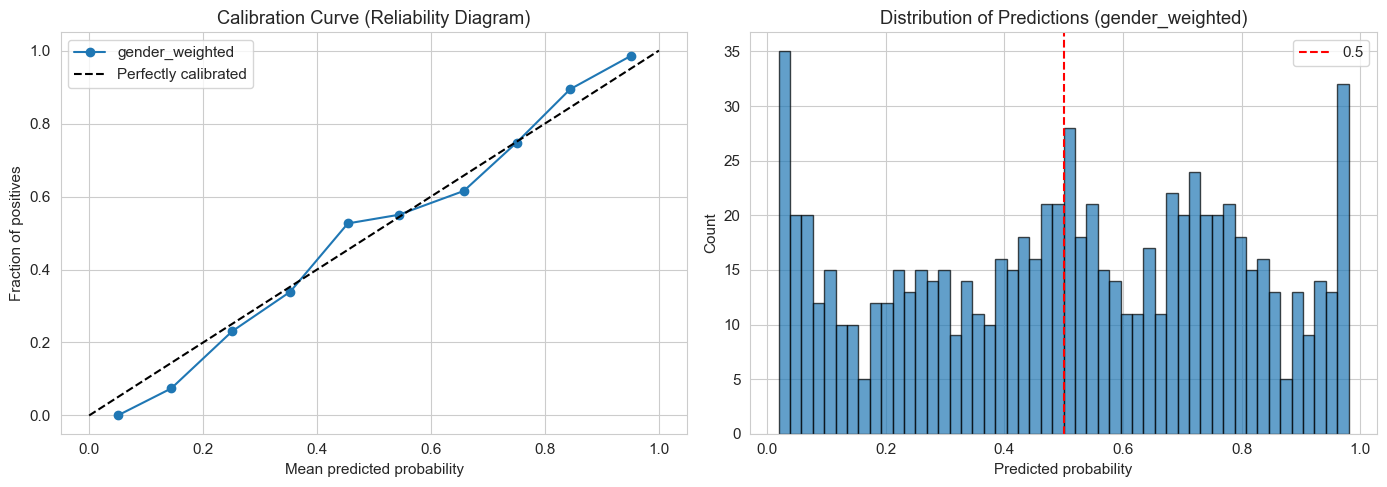

Expected Calibration Error (ECE): 0.0362


In [30]:
# Calibration plot for best ensemble
# Note: best_oof, val_mask, y_val_all are set by the "Pick best pre-calibration OOF" cell above.
# (best_oof is already clipped to [0.02, 0.98])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
prob_true, prob_pred = calibration_curve(y_val_all, best_oof, n_bins=10, strategy='uniform')
axes[0].plot(prob_pred, prob_true, 'o-', label=f'{best_name}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve (Reliability Diagram)')
axes[0].legend()
axes[0].grid(True)

# Prediction distribution
axes[1].hist(best_oof, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Distribution of Predictions ({best_name})')
axes[1].legend()

plt.tight_layout()
plt.show()

# ECE (Expected Calibration Error)
ece = np.mean(np.abs(prob_true - prob_pred))
print(f'Expected Calibration Error (ECE): {ece:.4f}')

### 11.2 Temperature Scaling

In [31]:
from scipy.special import logit, expit

def temperature_scale(preds, labels, temps=np.arange(0.5, 2.01, 0.05)):
    """Find optimal temperature for probability calibration."""
    logits = logit(np.clip(preds, 0.001, 0.999))
    best_t, best_brier = 1.0, brier_score_loss(labels, preds)

    for t in temps:
        calibrated = expit(logits / t)
        calibrated = np.clip(calibrated, 0.02, 0.98)
        b = brier_score_loss(labels, calibrated)
        if b < best_brier:
            best_brier = b
            best_t = t

    return best_t, best_brier

# Find optimal temperature using inner CV
print('=== Temperature Scaling ===')
print(f'Before calibration: Brier = {brier_score_loss(y_val_all, best_oof):.4f}')

best_temp, best_brier = temperature_scale(best_oof, y_val_all)
print(f'Optimal temperature: {best_temp:.2f}')
print(f'After calibration:  Brier = {best_brier:.4f}')

=== Temperature Scaling ===
Before calibration: Brier = 0.1583
Optimal temperature: 0.90
After calibration:  Brier = 0.1580


### 11.3 Clipping Optimization

In [32]:
# Test different clipping ranges
print('=== Clipping Optimization ===')
calibrated_oof = expit(logit(np.clip(best_oof, 0.001, 0.999)) / best_temp)

clip_results = {}
for lo, hi in [(0.01, 0.99), (0.02, 0.98), (0.03, 0.97), (0.05, 0.95), (0.08, 0.92), (0.10, 0.90)]:
    clipped = np.clip(calibrated_oof, lo, hi)
    b = brier_score_loss(y_val_all, clipped)
    clip_results[(lo, hi)] = b
    print(f'  Clip [{lo:.2f}, {hi:.2f}]: Brier = {b:.4f}')

best_clip = min(clip_results, key=clip_results.get)
print(f'\nBest clip range: {best_clip} -> Brier = {clip_results[best_clip]:.4f}')

=== Clipping Optimization ===
  Clip [0.01, 0.99]: Brier = 0.1580
  Clip [0.02, 0.98]: Brier = 0.1580
  Clip [0.03, 0.97]: Brier = 0.1580
  Clip [0.05, 0.95]: Brier = 0.1582
  Clip [0.08, 0.92]: Brier = 0.1588
  Clip [0.10, 0.90]: Brier = 0.1595

Best clip range: (0.01, 0.99) -> Brier = 0.1580


In [33]:
# === 11.4 Seed-Prior Blending ===
# Blend model predictions with historical seed matchup win rates (Bayesian prior).
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# Build seed prior: P(lower ID wins | seed_diff) from all training data
train_with_seeds = matchup_df.dropna(subset=['diff_seed'])
seed_wr_table = train_with_seeds.groupby('diff_seed')['Label'].mean().to_dict()

# Calibrated predictions
calibrated_final = np.clip(
    expit(logit(np.clip(best_oof, 0.001, 0.999)) / best_temp),
    best_clip[0], best_clip[1]
)

# Seed prior for each OOF sample
oof_seed_diff = matchup_df.loc[val_mask, 'diff_seed'].values
seed_prior_oof = np.array([
    seed_wr_table.get(sd, 0.5) if pd.notna(sd) else 0.5
    for sd in oof_seed_diff
])

# Optimize alpha: final = alpha * model + (1-alpha) * seed_prior
def blend_brier(alpha):
    blended = alpha * calibrated_final + (1 - alpha) * seed_prior_oof
    return brier_score_loss(y_val_all, np.clip(blended, best_clip[0], best_clip[1]))

res = minimize_scalar(blend_brier, bounds=(0.5, 1.0), method='bounded')
best_alpha = res.x
blended_brier = res.fun

print('=== Seed-Prior Blending ===')
print(f'  Model only:          Brier = {clip_results[best_clip]:.4f}')
print(f'  Optimal alpha:       {best_alpha:.3f}  (model weight)')
print(f'  After seed blending: Brier = {blended_brier:.4f}')
print(f'  Improvement:         {clip_results[best_clip] - blended_brier:+.4f}')

print('\n  Seed Prior table (key matchups):')
for sd in sorted(seed_wr_table.keys()):
    if sd == int(sd) and abs(sd) <= 8:
        n = (train_with_seeds['diff_seed'] == sd).sum()
        print(f'    seed_diff={sd:+3.0f}: P(lower wins) = {seed_wr_table[sd]:.3f}  (n={n})')

=== Seed-Prior Blending ===
  Model only:          Brier = 0.1580
  Optimal alpha:       0.925  (model weight)
  After seed blending: Brier = 0.1579
  Improvement:         +0.0001

  Seed Prior table (key matchups):
    seed_diff= -8: P(lower wins) = 0.800  (n=115)
    seed_diff= -7: P(lower wins) = 0.774  (n=115)
    seed_diff= -6: P(lower wins) = 0.833  (n=6)
    seed_diff= -5: P(lower wins) = 0.667  (n=126)
    seed_diff= -4: P(lower wins) = 0.794  (n=68)
    seed_diff= -3: P(lower wins) = 0.671  (n=161)
    seed_diff= -2: P(lower wins) = 0.727  (n=22)
    seed_diff= -1: P(lower wins) = 0.571  (n=210)
    seed_diff= +0: P(lower wins) = 0.500  (n=116)
    seed_diff= +1: P(lower wins) = 0.472  (n=199)
    seed_diff= +2: P(lower wins) = 0.300  (n=30)
    seed_diff= +3: P(lower wins) = 0.352  (n=165)
    seed_diff= +4: P(lower wins) = 0.269  (n=52)
    seed_diff= +5: P(lower wins) = 0.366  (n=123)
    seed_diff= +6: P(lower wins) = 0.625  (n=8)
    seed_diff= +7: P(lower wins) = 0.270  

## 12. Final Summary

In [34]:
final_brier = blended_brier  # best after all calibration steps

print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
all_scores = {
    'Naive (0.5)':             0.25,
    'Seed-only':               seed_brier,
    'LR (key feats)':          lr_results['overall_brier'],
    'LR (selected feats)':     lr_full_results['overall_brier'],
    'LGB baseline':            lgb_base_results['overall_brier'],
    'LGB tuned (Optuna)':      lgb_tuned_results['overall_brier'],
    'XGBoost':                 xgb_results['overall_brier'],
    'CatBoost':                cb_results['overall_brier'],
    'Simple Average':          simple_avg_brier,
    'Weighted Average':        weighted_avg_brier,
    'Gender-specific (M+W)':   gender_ensemble_brier,
    'Ridge Stacking (gender)': stack_brier,
}
all_scores['+ Temp Scaling'] = best_brier
all_scores['+ Optimal Clip'] = clip_results[best_clip]
all_scores['+ Seed-Prior Blend'] = blended_brier

for name, score in all_scores.items():
    marker = ' <-- BEST' if score == min(all_scores.values()) else ''
    print(f'  {name:28s}: Brier = {score:.4f}{marker}')

print(f'\nImprovement over naive:     {(0.25 - final_brier) / 0.25 * 100:.1f}%')
print(f'Improvement over seed-only: {(seed_brier - final_brier) / seed_brier * 100:.1f}%')

# Per-gender breakdown on CV val set
print('\n--- Per-Gender Breakdown (CV val set, after calibration) ---')
if 'Gender' in matchup_df.columns:
    m_mask_val = val_mask & (matchup_df['Gender'] == 'M').values
    w_mask_val = val_mask & (matchup_df['Gender'] == 'W').values
    # calibrated_final is from the seed-prior blending cell (best_oof after all calibration)
    for gender_mask, lbl in [(m_mask_val, 'Men'), (w_mask_val, 'Women')]:
        sub_mask_in_val = gender_mask[val_mask]
        if sub_mask_in_val.sum() > 0:
            g_brier = brier_score_loss(y_val_all[sub_mask_in_val],
                                       calibrated_final[sub_mask_in_val])
            print(f'  {lbl}: Brier = {g_brier:.4f}  (n={sub_mask_in_val.sum()})')

FINAL RESULTS SUMMARY
  Naive (0.5)                 : Brier = 0.2500
  Seed-only                   : Brier = 0.1770
  LR (key feats)              : Brier = 0.1661
  LR (selected feats)         : Brier = 0.1666
  LGB baseline                : Brier = 0.1709
  LGB tuned (Optuna)          : Brier = 0.1595
  XGBoost                     : Brier = 0.1681
  CatBoost                    : Brier = 0.1647
  Simple Average              : Brier = 0.1625
  Weighted Average            : Brier = 0.1595
  Gender-specific (M+W)       : Brier = 0.1583
  Ridge Stacking (gender)     : Brier = 0.1657
  + Temp Scaling              : Brier = 0.1580
  + Optimal Clip              : Brier = 0.1580
  + Seed-Prior Blend          : Brier = 0.1579 <-- BEST

Improvement over naive:     36.8%
Improvement over seed-only: 10.8%

--- Per-Gender Breakdown (CV val set, after calibration) ---
  Men: Brier = 0.1861  (n=401)
  Women: Brier = 0.1294  (n=394)


## 13. Generate Submission

### 13.1 Train final models on all available data

In [35]:
# === 13.1 Train gender-specific final models on ALL training data ===
print('=== Training Gender-Specific Final Models (all data, with RS augmentation) ===')

# 🎯 Imputation medians (computed from tournament data, saved for inference) 🎯
m_fill = matchup_m[selected_features_m].median()
w_fill = matchup_w[selected_features_w].median()

# 🎯 Training sets: augmented (tourney + RS) 🎯
X_m_all  = matchup_m_aug[selected_features_m].fillna(m_fill)
y_m_all  = matchup_m_aug['Label']
sw_m_all = matchup_m_aug['sample_weight']

X_w_all  = matchup_w_aug[selected_features_w].fillna(w_fill)
y_w_all  = matchup_w_aug['Label']
sw_w_all = matchup_w_aug['sample_weight']

xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': 'logloss',
    'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 30,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0, 'seed': 42, 'verbosity': 0,
}

def train_gender_models(X_all, y_all, sw_all, X_tourney, y_tourney,
                         lgb_results, xgb_results_g, cb_results_g, label):
    """Train LGB+XGB+CatBoost+Spread for one gender on all available data."""
    print(f'\n  --- {label} ({len(y_all):,} games, {X_all.shape[1]} features) ---')
    sw = sw_all.values if hasattr(sw_all, 'values') else sw_all

    # LightGBM
    print('    LightGBM...')
    n_rounds = int(np.median([m.best_iteration for m in lgb_results['models']]))
    lgb_mod = lgb.train(
        best_lgb_params,
        lgb.Dataset(X_all, label=y_all, weight=sw),
        num_boost_round=n_rounds
    )

    # XGBoost
    print('    XGBoost...')
    n_xgb = int(np.median([m.best_iteration for m in xgb_results_g['models']]))
    xgb_mod = xgb.train(
        xgb_params,
        xgb.DMatrix(X_all, label=y_all, weight=sw),
        num_boost_round=max(n_xgb, 100)
    )

    # CatBoost
    print('    CatBoost...')
    cb_mod = cb.CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=5,
        l2_leaf_reg=3.0, subsample=0.8, verbose=0, random_seed=42,
    )
    cb_mod.fit(X_all, y_all, sample_weight=sw, verbose=0)

    # Spread regression (tournament-only; Cauchy loss)
    print('    Spread regressor...')
    y_margin_vals = _spread_target(pd.DataFrame({'ScoreDiff': X_tourney.index.map(
        lambda i: matchup_df.loc[i, 'ScoreDiff'] if i in matchup_df.index else 0
    ), 'Label': y_tourney}))
    spread_mod = xgb.train(
        _xgb_spread_params,
        xgb.DMatrix(X_tourney.fillna(0), label=y_margin_vals),
        num_boost_round=500, obj=cauchy_obj, verbose_eval=False
    )

    return lgb_mod, xgb_mod, cb_mod, spread_mod


# Tournament-only sets for MLP and spread regression
X_m_tourney = matchup_m[selected_features_m].fillna(m_fill)
y_m_tourney = matchup_m['Label']
X_w_tourney = matchup_w[selected_features_w].fillna(w_fill)
y_w_tourney = matchup_w['Label']

(final_lgb_m, final_xgb_m, final_cb_m,
 final_spread_m) = train_gender_models(
    X_m_all, y_m_all, sw_m_all, X_m_tourney, y_m_tourney,
    lgb_m, xgb_m, cb_m, 'Men'
)
(final_lgb_w, final_xgb_w, final_cb_w,
 final_spread_w) = train_gender_models(
    X_w_all, y_w_all, sw_w_all, X_w_tourney, y_w_tourney,
    lgb_w, xgb_w, cb_w, 'Women'
)

# 🎯 Train final Ridge meta-learner on all tournament OOF 🎯
print('\n  Ridge meta-learner (on all tournament OOF)...')
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
meta_imp_final = SimpleImputer(strategy='median')
X_meta_all = meta_imp_final.fit_transform(meta_X[val_mask_gender])
y_meta_all  = matchup_df.loc[val_mask_gender, 'Label'].values
final_ridge = Ridge(alpha=1.0)
final_ridge.fit(X_meta_all, y_meta_all)

print('\nAll final models trained (augmented with regular season data)!')

=== Training Gender-Specific Final Models (all data, with RS augmentation) ===

  --- Men (120,650 games, 20 features) ---
    LightGBM...
    XGBoost...
    CatBoost...
    Spread regressor...

  --- Women (117,351 games, 18 features) ---
    LightGBM...
    XGBoost...
    CatBoost...
    Spread regressor...

  Ridge meta-learner (on all tournament OOF)...

All final models trained (augmented with regular season data)!


In [36]:
# === predict_with_stacking: gender-specific 4-model prediction + Ridge + calibration ===

def predict_with_stacking(df, feat_cols_m, feat_cols_w, m_fill, w_fill):
    """
    1. Predict with gender-specific base models (LGB/XGB/CB/Spread).
    2. Stack with Ridge meta-learner or fall back to weighted average.
    Missing feature columns (e.g. h2h features absent in stage1_df) are filled
    with the training-set median stored in m_fill / w_fill.
    """
    def _get_X(df_sub, feat_cols, fill):
        """Return a DataFrame with exactly feat_cols columns; missing ones → fill value."""
        missing = [c for c in feat_cols if c not in df_sub.columns]
        if missing:
            df_sub = df_sub.copy()
            for c in missing:
                df_sub[c] = fill.get(c, 0) if hasattr(fill, 'get') else 0
        return df_sub[feat_cols].fillna(fill)

    is_mens = (df['TeamA'] < 2000).values
    n = len(df)
    base_preds = np.full((n, 4), np.nan)   # [LGB, XGB, CB, Spread]

    # ---- Men ----
    if is_mens.sum() > 0:
        X_m = _get_X(df[is_mens], feat_cols_m, m_fill)
        base_preds[is_mens, 0] = final_lgb_m.predict(X_m)
        base_preds[is_mens, 1] = final_xgb_m.predict(xgb.DMatrix(X_m))
        base_preds[is_mens, 2] = final_cb_m.predict_proba(X_m)[:, 1]
        raw_margin_m = final_spread_m.predict(xgb.DMatrix(X_m))
        base_preds[is_mens, 3] = np.clip(iso_m.predict(raw_margin_m), 0.02, 0.98)

    # ---- Women ----
    if (~is_mens).sum() > 0:
        X_w = _get_X(df[~is_mens], feat_cols_w, w_fill)
        base_preds[~is_mens, 0] = final_lgb_w.predict(X_w)
        base_preds[~is_mens, 1] = final_xgb_w.predict(xgb.DMatrix(X_w))
        base_preds[~is_mens, 2] = final_cb_w.predict_proba(X_w)[:, 1]
        raw_margin_w = final_spread_w.predict(xgb.DMatrix(X_w))
        base_preds[~is_mens, 3] = np.clip(iso_w.predict(raw_margin_w), 0.02, 0.98)

    # ---- Combine ----
    if best_name == 'ridge_stacking':
        ctx_vals = np.column_stack([
            df[c].fillna(0).values for c in meta_ctx_cols
        ]) if meta_ctx_cols else np.empty((n, 0))
        meta_feats = np.hstack([base_preds, ctx_vals])
        meta_feats = meta_imp_final.transform(meta_feats)
        ensemble = np.clip(final_ridge.predict(meta_feats), 0.02, 0.98)
    elif best_name == 'gender_weighted':
        nw = len(opt_weights_m)
        ensemble = np.where(
            is_mens,
            base_preds[:, :nw] @ opt_weights_m,
            base_preds[:, :nw] @ opt_weights_w,
        )
    else:
        # Unified weighted average — pad to 4 if needed
        w4 = np.append(opt_weights, 0) if len(opt_weights) < 4 else opt_weights[:4]
        w4 = w4 / w4.sum()
        ensemble = base_preds @ w4

    return ensemble


print('predict_with_stacking defined (4 base models: LGB/XGB/CB/Spread)')

predict_with_stacking defined (4 base models: LGB/XGB/CB/Spread)


In [43]:
# === 13.2 Stage1 Validation (Backtest 2022-2025) ===
# Stage1 has known results → immediate Kaggle Brier score after upload.
# Note: final models trained on all data including 2022-2025, so slightly optimistic;
# the unbiased estimate is the CV Brier above.
from src.data_loader import load_all_data, load_tourney_compact, build_tourney_labels

print('Building Stage1 features (all 2022-2025 matchups)...')
stage1_df, _, _ = run_feature_pipeline(target='stage1', use_massey=True)

# Predict using gender-specific models
preds_s1 = predict_with_stacking(stage1_df, selected_features_m, selected_features_w,
                                  m_fill, w_fill)

# Temperature → seed-prior → clip
preds_s1_cal     = expit(logit(np.clip(preds_s1, 0.001, 0.999)) / best_temp)
seed_prior_s1    = stage1_df['diff_seed'].map(seed_wr_table).fillna(0.5).values
preds_s1_blended = best_alpha * preds_s1_cal + (1 - best_alpha) * seed_prior_s1
preds_s1_final   = np.clip(preds_s1_blended, best_clip[0], best_clip[1])

# Save Stage1 submission
sub_s1  = pd.DataFrame({'ID': stage1_df['ID'], 'Pred': preds_s1_final})
out_s1  = PROJECT_DIR / 'submissions' / 'stage1' / 'submission_ensemble_v1.csv'
os.makedirs(out_s1.parent, exist_ok=True)
sub_s1.to_csv(out_s1, index=False)
print(f'Stage1 submission saved: {out_s1}  ({len(sub_s1)} rows)')

# Evaluate against actual results
_data   = load_all_data()
_tc     = load_tourney_compact(_data)
_labels = build_tourney_labels(_tc)
s1_actual = _labels[_labels['Season'].isin([2022, 2023, 2024, 2025])].copy()
s1_eval   = sub_s1.merge(s1_actual[['ID', 'Label', 'Gender']], on='ID', how='inner')

if len(s1_eval) > 0:
    s1_brier = brier_score_loss(s1_eval['Label'], s1_eval['Pred'])
    print(f'\nSanity-check Brier (optimistic, {len(s1_eval)} games): {s1_brier:.4f}')
    print(f'Unbiased CV estimate:                                    {final_brier:.4f}')
    s1_eval['Season'] = s1_eval['ID'].str[:4].astype(int)
    print('\nPer season:')
    for season, g in s1_eval.groupby('Season'):
        print(f'  {season}: Brier={brier_score_loss(g["Label"], g["Pred"]):.4f}  n={len(g)}')
    print('\nPer gender:')
    for gender, g in s1_eval.groupby('Gender'):
        lbl = 'Men' if gender == 'M' else 'Women'
        print(f'  {lbl}: Brier={brier_score_loss(g["Label"], g["Pred"]):.4f}  n={len(g)}')

Building Stage1 features (all 2022-2025 matchups)...
LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanc

### 13.3 Generate Stage 2 Predictions

In [38]:
# Load Stage2 submission template and build features
print('Building Stage 2 features...')
stage2_df, stage2_feat_cols, _ = run_feature_pipeline(target='stage2', use_massey=True)

# Ensure selected features are available
missing_feats = [f for f in selected_features if f not in stage2_df.columns]
if missing_feats:
    print(f'Warning: {len(missing_feats)} features missing in stage2, filling with 0')
    for f in missing_feats:
        stage2_df[f] = 0

X_stage2 = stage2_df[selected_features]
print(f'Stage 2 shape: {X_stage2.shape}')

Building Stage 2 features...
LOADING DATA
Loaded 35 files: ['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeamSpellings', 'MTeams', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSeasons', 'WSecondaryTourneyCompactResults', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeamSpellings', 'WTeams']

COMPUTING TEAM-SEASON FEATURES

[1/7] Basic season statistics...
  -> 14311 team-seasons, 30 cols

[2/7] Advanced basketball statistics

Predicting Stage 2 with gender-specific models...
Method: gender_weighted
Predictions  mean=0.498  std=0.334  min=0.010  max=0.990


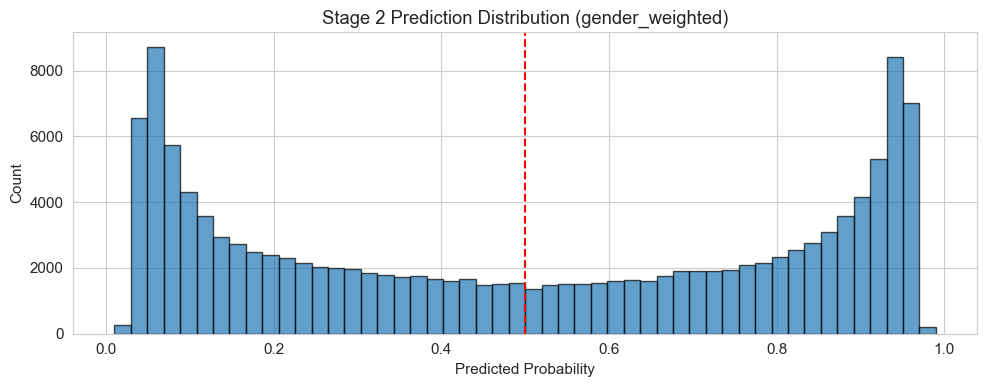

In [39]:
# === 13.3 Generate Stage 2 Predictions ===
print('Predicting Stage 2 with gender-specific models...')
ensemble_pred = predict_with_stacking(stage2_df, selected_features_m, selected_features_w,
                                       m_fill, w_fill)

# Temperature scaling & seed-prior blending & clip
ensemble_cal     = expit(logit(np.clip(ensemble_pred, 0.001, 0.999)) / best_temp)
seed_prior_s2    = stage2_df['diff_seed'].map(seed_wr_table).fillna(0.5).values
ensemble_blended = best_alpha * ensemble_cal + (1 - best_alpha) * seed_prior_s2
ensemble_pred_final = np.clip(ensemble_blended, best_clip[0], best_clip[1])

print(f'Method: {best_name}')
print(f'Predictions  mean={ensemble_pred_final.mean():.3f}  '
      f'std={ensemble_pred_final.std():.3f}  '
      f'min={ensemble_pred_final.min():.3f}  max={ensemble_pred_final.max():.3f}')

plt.figure(figsize=(10, 4))
plt.hist(ensemble_pred_final, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title(f'Stage 2 Prediction Distribution ({best_name})')
plt.axvline(0.5, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [40]:
# Save Stage2 submission
submission = pd.DataFrame({'ID': stage2_df['ID'], 'Pred': ensemble_pred_final})
out_path = PROJECT_DIR / 'submissions' / 'stage2' / 'submission_ensemble_v1.csv'
os.makedirs(out_path.parent, exist_ok=True)
submission.to_csv(out_path, index=False)

print(f'Submission saved: {out_path}')
print(f'Shape: {submission.shape}')
print(submission.head(10).to_string(index=False))

# Verify format
sample = pd.read_csv(DATA_DIR / 'SampleSubmissionStage2.csv')
assert len(submission) == len(sample), f'Row count mismatch: {len(submission)} vs {len(sample)}'
assert list(submission.columns) == list(sample.columns), 'Column mismatch'
print(f'\nFormat verified: {len(submission)} rows, columns match sample submission.')

Submission saved: /Users/felixhuang/Desktop/2026 MM/submissions/stage2/submission_ensemble_v1.csv
Shape: (132133, 2)
            ID     Pred
2026_1101_1102 0.757013
2026_1101_1103 0.073664
2026_1101_1104 0.062392
2026_1101_1105 0.763932
2026_1101_1106 0.808484
2026_1101_1107 0.753327
2026_1101_1108 0.831186
2026_1101_1110 0.521384
2026_1101_1111 0.240443
2026_1101_1112 0.058507

Format verified: 132133 rows, columns match sample submission.


---

## Appendix: Configuration & Hyperparameters

In [41]:
print('=== Final Configuration ===')
print(f'Features used: {len(selected_features)}')
print(f'LGB best params: {best_lgb_params}')
print(f'Ensemble weights: {dict(zip(model_names, opt_weights))}')
print(f'Temperature: {best_temp}')
print(f'Clip range: {best_clip}')
print(f'\nBest overall Brier on CV: {final_brier:.4f}')

=== Final Configuration ===
Features used: 20
LGB best params: {'objective': 'binary', 'metric': 'binary_logloss', 'verbose': -1, 'n_jobs': -1, 'seed': 42, 'learning_rate': 0.10221986077074957, 'num_leaves': 20, 'max_depth': 6, 'min_child_samples': 72, 'feature_fraction': 0.5004120150205564, 'bagging_fraction': 0.7681892985334657, 'bagging_freq': 2, 'reg_alpha': 0.0268019203233604, 'reg_lambda': 0.022981674850181717}
Ensemble weights: {'lgb_tuned': np.float64(0.9533523208321919), 'xgb': np.float64(0.0), 'catboost': np.float64(0.04664767916780812)}
Temperature: 0.9000000000000004
Clip range: (0.01, 0.99)

Best overall Brier on CV: 0.1579


In [42]:
import re
import pandas as pd
import numpy as np

# ── 1. ENSEMBLE WEIGHTS ──────────────────────────────────────────────────────
model_labels = ['LGB', 'XGB', 'CatBoost', 'LR', 'MLP']

print('=' * 58)
print('  ENSEMBLE WEIGHTS  (Gender-Specific Weighted Average)')
print('=' * 58)
print(f'  {"Model":<12} {"Men (w)":>10} {"Women (w)":>10}')
print('  ' + '-' * 34)
for lbl, wm, ww in zip(model_labels, opt_weights_m, opt_weights_w):
    bar_m = '█' * int(round(wm * 20))
    bar_w = '█' * int(round(ww * 20))
    print(f'  {lbl:<12} {wm:>7.3f}  {bar_m:<20}  {ww:>7.3f}  {bar_w}')
print('  ' + '-' * 34)
print(f'  {"CV Brier":<12} {men_brier:>10.4f} {women_brier:>10.4f}')
print(f'\n  Calibration  →  temperature={best_temp:.4f}  '
      f'alpha(model)={best_alpha:.3f}  clip={best_clip}')
print(f'  Method selected: {best_name}')

# ── 2. HELPERS ───────────────────────────────────────────────────────────────
teams_df  = pd.read_csv(DATA_DIR / 'MTeams.csv')
wteams_df = pd.read_csv(DATA_DIR / 'WTeams.csv')

def team_name(tid, is_mens):
    df = teams_df if is_mens else wteams_df
    row = df[df['TeamID'] == tid]
    return row['TeamName'].values[0] if len(row) else str(tid)

def parse_seed_num(s):
    m = re.search(r'(\d+)', s)
    return int(m.group(1)) if m else 99

pred_lookup = dict(zip(submission['ID'], submission['Pred']))

def win_prob(ta, tb):
    lo, hi = sorted([ta, tb])
    p = pred_lookup.get(f'2026_{lo}_{hi}', 0.5)
    return p if ta == lo else 1.0 - p

# ── 3. BRACKET SIMULATOR ─────────────────────────────────────────────────────
ROUND_NAMES = ['R64', 'R32', 'S16', 'E8']
SEED_ORDER  = [1, 16, 8, 9, 5, 12, 4, 13, 6, 11, 3, 14, 7, 10, 2, 15]

def simulate_bracket(seeds_csv_name, is_mens):
    seeds_df = pd.read_csv(DATA_DIR / seeds_csv_name)
    seeds_df = seeds_df[seeds_df['Season'] == 2026].copy()
    seeds_df['seed_num'] = seeds_df['Seed'].apply(parse_seed_num)
    seeds_df['region']   = seeds_df['Seed'].str[0]
    name_map = {tid: team_name(tid, is_mens) for tid in seeds_df['TeamID']}
    log = []

    region_finalists = []
    for region in sorted(seeds_df['region'].unique()):
        reg = seeds_df[seeds_df['region'] == region]
        s2t = dict(zip(reg['seed_num'], reg['TeamID']))
        bracket = [s2t[s] for s in SEED_ORDER if s in s2t]

        for rname in ROUND_NAMES:
            if len(bracket) <= 1:
                break
            nxt = []
            for i in range(0, len(bracket), 2):
                ta, tb = bracket[i], bracket[i + 1]
                p = win_prob(ta, tb)
                winner = ta if p >= 0.5 else tb
                log.append({'Round': rname, 'Region': region,
                            'TeamA': name_map[ta], 'TeamB': name_map[tb],
                            'P(A wins)': round(p, 3), 'Winner': name_map[winner]})
                nxt.append(winner)
            bracket = nxt
        region_finalists.extend(bracket)

    ff_winners = []
    for i in range(0, len(region_finalists), 2):
        ta, tb = region_finalists[i], region_finalists[i + 1]
        p = win_prob(ta, tb)
        winner = ta if p >= 0.5 else tb
        log.append({'Round': 'F4', 'Region': 'Final Four',
                    'TeamA': name_map[ta], 'TeamB': name_map[tb],
                    'P(A wins)': round(p, 3), 'Winner': name_map[winner]})
        ff_winners.append(winner)

    if len(ff_winners) == 2:
        ta, tb = ff_winners
        p = win_prob(ta, tb)
        champ = ta if p >= 0.5 else tb
        log.append({'Round': 'Championship', 'Region': 'National',
                    'TeamA': name_map[ta], 'TeamB': name_map[tb],
                    'P(A wins)': round(p, 3), 'Winner': name_map[champ]})

    return pd.DataFrame(log)

# ── 4. SIMULATE & DISPLAY ────────────────────────────────────────────────────
late_rounds = ['E8', 'F4', 'Championship']
pd.set_option('display.max_colwidth', 25)
pd.set_option('display.width', 110)

print('\n' + '=' * 58)
print("  2026 MEN'S BRACKET — Late Rounds")
print('=' * 58)
m_bracket = simulate_bracket('MNCAATourneySeeds.csv', is_mens=True)
print(m_bracket[m_bracket['Round'].isin(late_rounds)].to_string(index=False))

print('\n' + '=' * 58)
print("  2026 WOMEN'S BRACKET — Late Rounds")
print('=' * 58)
w_bracket = simulate_bracket('WNCAATourneySeeds.csv', is_mens=False)
print(w_bracket[w_bracket['Round'].isin(late_rounds)].to_string(index=False))

m_champ = m_bracket[m_bracket['Round'] == 'Championship']['Winner'].values[0]
w_champ = w_bracket[w_bracket['Round'] == 'Championship']['Winner'].values[0]
print(f"\n🏆 2026 Predicted Men's Champion:   {m_champ}")
print(f"🏆 2026 Predicted Women's Champion: {w_champ}")

# ── 5. SAVE ──────────────────────────────────────────────────────────────────
bracket_out = PROJECT_DIR / 'submissions' / 'stage2'
os.makedirs(bracket_out, exist_ok=True)
m_bracket.to_csv(bracket_out / 'bracket_2026_mens.csv', index=False)
w_bracket.to_csv(bracket_out / 'bracket_2026_womens.csv', index=False)
print(f'Full brackets saved to {bracket_out}/')

  ENSEMBLE WEIGHTS  (Gender-Specific Weighted Average)
  Model           Men (w)  Women (w)
  ----------------------------------
  LGB            0.451  █████████               0.287  ██████
  XGB            0.000                          0.000  
  CatBoost       0.549  ███████████             0.713  ██████████████
  ----------------------------------
  CV Brier         0.1862     0.1299

  Calibration  →  temperature=0.9000  alpha(model)=0.925  clip=(0.01, 0.99)
  Method selected: gender_weighted

  2026 MEN'S BRACKET — Late Rounds
       Round     Region    TeamA       TeamB  P(A wins)   Winner
          E8          W     Duke Michigan St      0.768     Duke
          E8          X  Florida    Illinois      0.525  Florida
          E8          Y Michigan     Iowa St      0.668 Michigan
          E8          Z  Arizona      Purdue      0.598  Arizona
          F4 Final Four     Duke     Florida      0.514     Duke
          F4 Final Four Michigan     Arizona      0.474  Arizona
Champi